# ML Analysis — Dividend Initiations & Omissions

**Thesis:** *When Firms Start and Stop Paying: Machine Learning Evidence on Dividend Initiation and Omission*
**Author:** Matyáš Ležatka · Utrecht University · June 2026

This notebook contains the thesis-facing machine-learning analysis: a six-model rolling-window horse race, out-of-sample XGBoost SHAP interpretation, investor screening, statistical tests, and named case studies.

| Section | Thesis output |
|---|---|
| §5–§6 | Tables 5.3–5.4: walk-forward performance |
| §7 | Table A.1: paired Wilcoxon tests with Bonferroni correction |
| §8 | Figure 5.1: SHAP beeswarm |
| §9–§10 | Figure 5.2, Table 5.5: size-adjusted theory-block dynamics and winning variables |
| §11–§12 | Table 5.6, Figure 5.3, Table A.2: investor screening |
| §13–§16 | Figures 5.4–5.5, Appendix B.1: local SHAP case studies |

**Design invariants**
- Predictors are the 34 selected `_lag1` columns; same-year variables never enter models.
- Each fold trains on `[t−10, t−1]` and tests on year `t` — no future information leaks into training.
- Imputation, scaling, and class weights are fitted inside each training fold only.
- `F1@top-k` flags the `k` highest-scored observations per fold, where `k` equals the actual event count.

## §1 — Imports & paths


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pathlib
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, brier_score_loss, f1_score,
)

import xgboost as xgb
import lightgbm as lgb
import shap

print(f"XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}  |  SHAP {shap.__version__}")


XGBoost 3.2.0  |  LightGBM 4.6.0  |  SHAP 0.51.0


In [2]:
PROJECT_DIR = pathlib.Path.cwd()
DATA_DIR    = PROJECT_DIR / 'data'
RESULTS     = PROJECT_DIR / 'results'
FIGS_DIR   = RESULTS / 'figures'
TABLES_DIR = RESULTS / 'tables'
for d in (FIGS_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42

UU_GREEN  = '#007A33'
UU_RED    = '#C00A35'
UU_BLUE   = '#002B7F'
UU_YELLOW = '#FFCD00'
UU_GRAY   = '#767676'
UU_DARK   = '#1A1A1A'
UU_CREAM  = '#F5F0E8'

plt.rcParams.update({
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

## §2 — Theory-block taxonomy

Maps all 34 lagged predictors to eight theoretical blocks drawn from the dividend policy literature (thesis Table 2.1). Each block groups variables that test the same economic mechanism, enabling size-adjusted SHAP aggregation in §9. Single-variable blocks (Transaction Cost, Catering) are retained for individual feature attribution but excluded from relative block comparisons because their normalised value is mechanically identical to their raw SHAP.

In [3]:
THEORY_BLOCKS = {
    'Life-Cycle &\nMaturity': [
        'RE_TE_lag1', 'RE_TA_lag1', 'TE_TA_lag1',
        'Size_lag1', 'Log_MarketCap_lag1',
        'Sales_Growth_lag1', 'Asset_Growth_lag1', 'Listing_Age_lag1',
    ],
    'Growth Options &\nInvestment': [
        'Market_to_Book_lag1', 'CapEx_to_Assets_lag1',
        'RD_assets_lag1', 'Price_to_Sales_lag1',
    ],
    'Signaling &\nProfitability': [
        'ROA_lag1', 'ROE_lag1', 'OpCF_to_Assets_lag1',
        'ORA_lag1', 'Profit_Margin_lag1', 'Accruals_lag1',
    ],
    'Free Cash Flow\n/ Agency': [
        'Cash_to_Assets_lag1', 'FCF_to_Assets_lag1',
        'Repurchase_to_Assets_lag1', 'Goodwill_to_Assets_lag1',
    ],
    'Conservatism\n& Risk': [
        'Leverage_lag1', 'LTDA_lag1', 'Current_Ratio_lag1',
        'Earnings_Volatility_lag1', 'Interest_Coverage_lag1',
        'FAT_lag1', 'LCTAT_lag1', 'Labor_Intensity_lag1',
    ],
    'Corporate\nTaxation': [
        'GAAP_ETR_lag1', 'Cash_ETR_lag1',
    ],
    'Transaction Cost\nTheory': [
        'Share_Turnover_lag1',                    # Kale, Kini & Payne (2012)
    ],
    'Catering Premium\n(Behavioral)': [
        'DIVPREM_lag1',                           # Baker & Wurgler (2004) catering theory
    ],
}

# Inverted map: feature → block label
FEAT_TO_BLOCK = {
    feat: block
    for block, feats in THEORY_BLOCKS.items()
    for feat in feats
}

# One distinct colour per block — 8-colour qualitative palette
BLOCK_COLORS = {
    'Life-Cycle &\nMaturity':         '#2166AC',   # blue
    'Growth Options &\nInvestment':    '#762A83',   # purple
    'Signaling &\nProfitability':      '#D7191C',   # red
    'Free Cash Flow\n/ Agency':        '#4DAC26',   # green
    'Conservatism\n& Risk':            '#F46D43',   # orange
    'Corporate\nTaxation':             '#8C510A',   # brown
    'Transaction Cost\nTheory':        '#878787',   # gray
    'Catering Premium\n(Behavioral)':  '#01665E',   # teal
}

# Short display labels for all 34 selected model features
SHORT_LABELS = {
    'RE_TE_lag1':                     'RE / TE',
    'RE_TA_lag1':                     'RE / TA',
    'TE_TA_lag1':                     'TE / TA',
    'Size_lag1':                      'Size (log TA)',
    'Log_MarketCap_lag1':             'Log Mkt Cap',
    'Sales_Growth_lag1':              'Sales Growth',
    'Asset_Growth_lag1':              'Asset Growth',
    'Listing_Age_lag1':               'Listing Age',
    'Market_to_Book_lag1':            'Mkt-to-Book',
    'CapEx_to_Assets_lag1':           'CapEx / Assets',
    'RD_assets_lag1':                 'R&D / Assets',
    'Price_to_Sales_lag1':            'Price / Sales',
    'ROA_lag1':                       'ROA',
    'ROE_lag1':                       'ROE',
    'OpCF_to_Assets_lag1':            'OpCF / Assets',
    'ORA_lag1':                       'ORA',
    'Profit_Margin_lag1':             'Profit Margin',
    'Accruals_lag1':                  'Accruals',
    'Cash_to_Assets_lag1':            'Cash / Assets',
    'FCF_to_Assets_lag1':             'FCF / Assets',
    'Repurchase_to_Assets_lag1':      'Repurchase / Assets',
    'Goodwill_to_Assets_lag1':        'Goodwill / Assets',
    'Leverage_lag1':                  'Leverage',
    'LTDA_lag1':                      'LT Debt / Assets',
    'Current_Ratio_lag1':             'Current Ratio',
    'Earnings_Volatility_lag1':       'Earnings Volatility',
    'Interest_Coverage_lag1':         'Interest Coverage',
    'FAT_lag1':                       'Fixed Asset Turn.',
    'LCTAT_lag1':                     'LC / TA',
    'Labor_Intensity_lag1':           'Labor Intensity',
    'GAAP_ETR_lag1':                  'GAAP ETR',
    'Cash_ETR_lag1':                  'Cash ETR',
    'Share_Turnover_lag1':            'Share Turnover',
    'DIVPREM_lag1':                   'Div. Premium',
}

# Sanity: all 34 selected features present across 8 blocks, no duplicates, no gaps
all_block_feats = [f for feats in THEORY_BLOCKS.values() for f in feats]
assert len(all_block_feats) == len(set(all_block_feats)) == 34, \
    f"Block taxonomy mismatch: {len(all_block_feats)} features across blocks"

print("Theory blocks OK — 34 selected features, 8 blocks, no overlaps.")
for block, feats in THEORY_BLOCKS.items():
    print(f"  {block.replace(chr(10), ' '):<35s}  {len(feats)} features")

Theory blocks OK — 34 selected features, 8 blocks, no overlaps.
  Life-Cycle & Maturity                8 features
  Growth Options & Investment          4 features
  Signaling & Profitability            6 features
  Free Cash Flow / Agency              4 features
  Conservatism & Risk                  8 features
  Corporate Taxation                   2 features
  Transaction Cost Theory              1 features
  Catering Premium (Behavioral)        1 features


## §3 — Data loading & verification

Loads the two ML-ready panels exported by `Data Sourcing.ipynb`. The 34 selected `_lag1` features are the model inputs; `Industry_Paying_Intensity_lag1` is excluded because it is a market-level variable that could introduce cross-sectional information leakage. `DIVPREM_lag1` (Baker & Wurgler, 2004) enters as a prior-year market-wide signal.

In [4]:
datasets = {
    'initiation': pd.read_csv(DATA_DIR / 'ml_dividend_initiations_1990_2025.csv'),
    'omission':   pd.read_csv(DATA_DIR / 'ml_dividend_omissions_1990_2025.csv'),
}

feature_map = pd.read_csv(DATA_DIR / 'ml_feature_list.csv')
EXCLUDED_FEATURES = {'Industry_Paying_Intensity_lag1'}
FEATURES = [
    c for c in feature_map['feature_model_column'].tolist()
    if c not in EXCLUDED_FEATURES
]
missing_features = sorted(set(FEATURES) - set(datasets['initiation'].columns))
assert not missing_features, f"Missing selected features in initiation CSV: {missing_features}"
assert len(FEATURES) == 34, f"Expected 34 selected features, found {len(FEATURES)}"

assert 'DIVPREM_lag1' in FEATURES, "Expected lagged dividend premium variable"
assert 'Industry_Paying_Intensity_lag1' not in FEATURES, "Industry paying intensity should be excluded"
print("Catering premium variable OK — DIVPREM_lag1 enters as a prior-year signal.")

print()
for task, df in datasets.items():
    target   = f'target_{task}'
    n_events = df[target].sum()
    rate     = n_events / len(df) * 100
    print(f"{task.capitalize():12s} │ {len(df):>6,} obs │ {int(n_events):>4,} events │ {rate:.2f}% event rate")

print(f"\nFeatures ({len(FEATURES)}): {FEATURES[:4]} ... {FEATURES[-3:]}")

Catering premium variable OK — DIVPREM_lag1 enters as a prior-year signal.

Initiation   │ 94,127 obs │ 2,858 events │ 3.04% event rate
Omission     │ 72,646 obs │ 2,925 events │ 4.03% event rate

Features (34): ['RE_TE_lag1', 'RE_TA_lag1', 'TE_TA_lag1', 'Size_lag1'] ... ['Cash_ETR_lag1', 'Share_Turnover_lag1', 'DIVPREM_lag1']


## §4 — Model configuration

Six classifiers compete in the horse race for both initiation and omission tasks: `Logit-unpenalized`, `Ridge`, `LASSO`, `RF`, `XGB`, and `LGB`. XGBoost is the SHAP anchor for both tasks.

**Why these six models.** The linear baseline (Logit) isolates the marginal gain from penalisation (Ridge, LASSO) and from non-linearity (RF, XGB, LGB). Including both gradient-boosting implementations (XGBoost, LightGBM) tests whether algorithmic differences matter for rare-event dividend prediction.

**Protocol**
- Rolling 10-year train window; test on year *t*; 26 folds (2000–2025).
- Linear models use median imputation with missing-value indicators plus standardisation.
- Random Forest uses median imputation only.
- XGBoost and LightGBM receive raw pandas frames so their native missing-value handling is retained.
- Class imbalance: `class_weight='balanced'` for linear models and RF; `scale_pos_weight = n_neg / n_pos` per fold for XGB and LGB.
- Ridge, RF, XGB, and LGB use `RandomizedSearchCV` with five chronological inner folds and `average_precision` scoring (Gu, Kelly & Xiu, 2020).
- LASSO is fixed at `C=0.1` by default; optional chronological `GridSearchCV` over `C=[0.01, 0.1, 1.0]`.

| Model | Fixed settings | Tuned hyperparameters |
|---|---|---|
| Logit-unpenalized | `penalty=None`, `solver='lbfgs'`, `max_iter=5000`, `class_weight='balanced'` | — |
| Ridge | `penalty='l2'`, `solver='lbfgs'`, `max_iter=1000`, `class_weight='balanced'` | `C = 1/λ`, `λ ∈ {0.05, 0.06, …, 2.05}` |
| LASSO | `penalty='l1'`, `solver='saga'`, `max_iter=10000`, `tol=1e-3`, `class_weight='balanced'` | Optional `C ∈ {0.01, 0.1, 1.0}` |
| Random Forest | `class_weight='balanced'` | `n_estimators ∈ {100, 500, 1000}`, `min_samples_leaf ∈ {1,…,21}`, `max_depth ∈ {1,…,25}` |
| XGBoost | `scale_pos_weight`, `eval_metric='aucpr'` | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree` |
| LightGBM | `n_estimators=500`, `scale_pos_weight` | `learning_rate`, `num_leaves`, `max_depth` |

In [5]:
TRAIN_WINDOW = 10
TEST_START   = 2000
TEST_END     = 2025
FOLDS        = list(range(TEST_START, TEST_END + 1))
TASKS        = ('initiation', 'omission')
MODEL_ORDER  = ['Logit-unpenalized', 'Ridge', 'LASSO', 'RF', 'XGB', 'LGB']

TUNE_LASSO = False
LASSO_C_DEFAULT = 0.1
LASSO_C_GRID = [0.01, 0.1, 1.0]
LASSO_INNER_CV_SPLITS = 3
LASSO_MAX_ITER = 10000
LASSO_TOL = 1e-3

RANDOM_SEARCH_ITER = 50
INNER_CV_SPLITS = 5

RIDGE_LAMBDAS = np.round(np.arange(0.05, 2.05 + 0.001, 0.01), 2)
RIDGE_C_GRID = (1 / RIDGE_LAMBDAS).tolist()

RF_PARAM_GRID = {
    'n_estimators': [100, 500, 1000],
    'min_samples_leaf': [1, 3, 5, 7, 11, 15, 20, 21],
    'max_depth': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
}

LGB_PARAM_GRID = {
    'learning_rate': [0.001, 0.005, 0.01, 0.1],
    'num_leaves': [2, 5, 7, 10, 20],
    'max_depth': [2, 5, 7, 10, 20],
}

XGB_PARAM_GRID = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.001, 0.005, 0.01, 0.1],
    'max_depth': [2, 5, 7, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}


CLASS_WEIGHT_LOGIT = 'balanced'
LOGIT_MAX_ITER = 5000

def make_unpenalized_logit():
    """
    Weighted but unpenalized logistic regression.
    Uses the same preprocessing as the other linear models.
    """
    try:
        return LogisticRegression(
            penalty=None,
            solver='lbfgs',
            max_iter=LOGIT_MAX_ITER,
            class_weight=CLASS_WEIGHT_LOGIT,
            random_state=SEED,
        )
    except TypeError:
        # For older scikit-learn versions
        return LogisticRegression(
            penalty='none',
            solver='lbfgs',
            max_iter=LOGIT_MAX_ITER,
            class_weight=CLASS_WEIGHT_LOGIT,
            random_state=SEED,
        )


def _safe_shap_values(explainer, X):
    """Return SHAP values as shape (n_samples, n_features) for the positive class.

    Handles legacy list output, current 2D binary output, and SHAP 0.51's
    3D binary classifier output shaped (n_samples, n_features, n_classes).
    """
    sv = explainer.shap_values(X)
    if isinstance(sv, list):        # [neg_class, pos_class]
        return sv[1]

    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[2] == 2:
        return sv[:, :, 1]
    if sv.ndim == 2:
        return sv
    raise ValueError(f"Unexpected SHAP values shape: {sv.shape}")


def f1_at_top_k(y_true, y_prob):
    """F1 after flagging the k highest scores, where k is the event count."""
    y_true = np.asarray(y_true).astype(int)
    k = int(y_true.sum())
    if k <= 0:
        return 0.0
    y_pred = np.zeros(len(y_prob), dtype=int)
    y_pred[np.argsort(y_prob)[-k:]] = 1
    return f1_score(y_true, y_pred, zero_division=0)


def make_temporal_inner_cv_splits(years, n_splits=LASSO_INNER_CV_SPLITS, min_train_years=4):
    """Chronological inner CV: validate on the last n_splits years of the train window."""
    years = pd.Series(years).astype(int).to_numpy()
    unique_years = np.sort(np.unique(years))
    if len(unique_years) < min_train_years + n_splits:
        raise ValueError(
            f"Need at least {min_train_years + n_splits} train years for {n_splits} inner splits; "
            f"got {len(unique_years)}"
        )

    splits = []
    for val_year in unique_years[-n_splits:]:
        train_idx = np.flatnonzero(years < val_year)
        val_idx = np.flatnonzero(years == val_year)
        if train_idx.size and val_idx.size:
            splits.append((train_idx, val_idx))

    if len(splits) != n_splits:
        raise ValueError(f"Built {len(splits)} inner splits, expected {n_splits}")
    return splits


def make_lasso_model(train_years):
    """Return fixed LASSO, or optional chronological inner-CV LASSO."""
    base = LogisticRegression(
        penalty='l1', solver='saga', class_weight='balanced',
        max_iter=LASSO_MAX_ITER, tol=LASSO_TOL, random_state=SEED,
    )
    if not TUNE_LASSO:
        base.set_params(C=LASSO_C_DEFAULT)
        return base

    return GridSearchCV(
        base,
        param_grid={'C': LASSO_C_GRID},
        cv=make_temporal_inner_cv_splits(train_years, n_splits=LASSO_INNER_CV_SPLITS),
        scoring='average_precision',
        n_jobs=-1,
        refit=True,
    )

def _grid_size(param_grid):
    """Return number of finite grid combinations."""
    return math.prod(len(values) for values in param_grid.values())


def make_random_search_model(estimator, param_grid, train_years):
    """Random search with chronological inner CV inside the rolling train window."""
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=min(RANDOM_SEARCH_ITER, _grid_size(param_grid)),
        cv=make_temporal_inner_cv_splits(
            train_years,
            n_splits=INNER_CV_SPLITS,
            min_train_years=4,
        ),
        scoring='average_precision',
        n_jobs=-1,
        random_state=SEED,
        refit=True,
    )

## §5 — Walk-forward horse race

Trains all six classifiers on each rolling 10-year window and records out-of-sample metrics. The rolling (rather than expanding) window lets models adapt to structural breaks in dividend policy — the 2003 tax reform, the 2008 financial crisis, the post-2010 payout surge — without older observations diluting the signal (Gu, Kelly & Xiu, 2020). XGBoost SHAP values and predictions are saved for every held-out firm-year to support all downstream explainability analysis.

In [6]:
import time


def build_model_bag(fold_spw, train_years,
                    X_tr_lin, X_te_lin, X_tr_rf, X_te_rf, X_tr_raw, X_te_raw):
    """Six-model bag: linear models get scaled data, RF gets imputed data,
    boosting models get raw frames for native missing-value handling."""
    return {
        'Logit-unpenalized': (
            make_unpenalized_logit(),
            X_tr_lin, X_te_lin,
        ),
        'Ridge': (
            make_random_search_model(
                LogisticRegression(
                    penalty='l2', solver='lbfgs', max_iter=1000,
                    class_weight='balanced', random_state=SEED,
                ),
                {'C': RIDGE_C_GRID}, train_years,
            ),
            X_tr_lin, X_te_lin,
        ),
        'LASSO': (
            make_lasso_model(train_years),
            X_tr_lin, X_te_lin,
        ),
        'RF': (
            make_random_search_model(
                RandomForestClassifier(
                    class_weight='balanced', random_state=SEED, n_jobs=-1,
                ),
                RF_PARAM_GRID, train_years,
            ),
            X_tr_rf, X_te_rf,
        ),
        'XGB': (
            make_random_search_model(
                xgb.XGBClassifier(
                    scale_pos_weight=fold_spw, random_state=SEED,
                    n_jobs=-1, verbosity=0, eval_metric='aucpr',
                ),
                XGB_PARAM_GRID, train_years,
            ),
            X_tr_raw, X_te_raw,
        ),
        'LGB': (
            make_random_search_model(
                lgb.LGBMClassifier(
                    n_estimators=500, scale_pos_weight=fold_spw,
                    random_state=SEED, n_jobs=-1, verbose=-1,
                ),
                LGB_PARAM_GRID, train_years,
            ),
            X_tr_raw, X_te_raw,
        ),
    }


def build_local_shap_frame(test_df, task, fold_year, target_col,
                           shap_values, xgb_prob):
    """Combine metadata, raw feature values, and SHAP values into one
    row-per-firm-year frame for downstream case studies and screening."""
    id_cols = [
        c for c in [
            'FirmID', 'FiscalYear', 'FiscalDate', 'Ticker', 'CUSIP',
            'CompanyName', target_col, 'DividendPaid',
            'DividendPaid_lag1', 'DividendPaid_lag2',
        ]
        if c in test_df.columns
    ]

    meta = test_df[id_cols].reset_index(drop=True).copy()
    meta.insert(0, 'task', task)
    meta.insert(1, 'fold', fold_year)
    meta['target_event'] = meta[target_col].astype(int)
    meta['shap_anchor'] = 'XGB'
    meta['pred_prob'] = xgb_prob
    meta['score_rank_in_fold'] = (
        pd.Series(xgb_prob)
          .rank(method='first', ascending=False)
          .astype(int)
          .to_numpy()
    )

    feature_vals = test_df[FEATURES].reset_index(drop=True).add_prefix('value_')
    shap_df = pd.DataFrame(shap_values,
                           columns=[f'shap_{f}' for f in FEATURES])

    return pd.concat([meta, feature_vals, shap_df], axis=1)


def impute_and_scale(X_train_raw, X_test_raw):
    """Median imputation with missing indicators + standardisation.
    Fitted on training fold only."""
    imp = SimpleImputer(strategy='median', add_indicator=True)
    sca = StandardScaler()
    X_tr = sca.fit_transform(imp.fit_transform(X_train_raw))
    X_te = sca.transform(imp.transform(X_test_raw))
    return X_tr, X_te


def impute_only(X_train_raw, X_test_raw):
    """Median imputation without scaling — for Random Forest.
    Fitted on training fold only."""
    imp = SimpleImputer(strategy='median')
    return imp.fit_transform(X_train_raw), imp.transform(X_test_raw)


records = []
shap_by_fold = {'initiation': {}, 'omission': {}}
local_shap_frames = []
_t0 = time.time()

for _fi, fold_year in enumerate(FOLDS, 1):
    train_years = range(fold_year - TRAIN_WINDOW, fold_year)
    _elapsed = time.time() - _t0
    _eta = (_elapsed / max(_fi - 1, 1)) * (len(FOLDS) - _fi + 1) if _fi > 1 else float('nan')
    print(f"\nFold {fold_year}  [{_fi:2d}/{len(FOLDS)}]  "
          f"elapsed {_elapsed/60:.1f} min  ETA ~{_eta/60:.1f} min", flush=True)

    for _ti, task in enumerate(TASKS, 1):
        df = datasets[task]
        target_col = f'target_{task}'

        tr = df[df['FiscalYear'].isin(train_years)]
        te = df[df['FiscalYear'] == fold_year]

        if len(te) == 0 or te[target_col].sum() == 0:
            print(f"  {task:10s} [{_ti}/2] skipped: no test data or events", flush=True)
            continue

        assert tr['FiscalYear'].max() < fold_year, \
            'Training window must end before the test year.'
        assert te['FiscalYear'].eq(fold_year).all(), \
            'Test fold contains an unexpected fiscal year.'

        X_tr_raw = tr[FEATURES].copy()
        y_tr = tr[target_col].values
        X_te_raw = te[FEATURES].copy()
        y_te = te[target_col].values

        X_tr_lin, X_te_lin = impute_and_scale(X_tr_raw, X_te_raw)
        X_tr_rf, X_te_rf = impute_only(X_tr_raw, X_te_raw)

        n_neg = int((y_tr == 0).sum())
        n_pos = int((y_tr == 1).sum())
        fold_spw = n_neg / max(n_pos, 1)

        model_bag = build_model_bag(
            fold_spw, tr['FiscalYear'],
            X_tr_lin, X_te_lin, X_tr_rf, X_te_rf, X_tr_raw, X_te_raw,
        )

        print(
            f"  {task:10s} [{_ti}/2] train={len(tr):,} test={len(te):,} "
            f"events={int(y_te.sum()):,} spw={fold_spw:.1f}",
            flush=True,
        )

        xgb_anchor_model = None
        xgb_anchor_prob = None

        for _mi, (mname, (model, X_train_m, X_test_m)) in enumerate(model_bag.items(), 1):
            _m0 = time.time()
            is_search = isinstance(model, (GridSearchCV, RandomizedSearchCV))
            print(f"    model {_mi}/{len(model_bag)} {mname}"
                  f"{', CV search' if is_search else ''} ... ",
                  end='', flush=True)

            model.fit(X_train_m, y_tr)
            fitted = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
            y_prob = fitted.predict_proba(X_test_m)[:, 1]

            pr_auc = average_precision_score(y_te, y_prob)

            records.append(dict(
                task=task, fold=fold_year, model=mname,
                pr_auc=pr_auc,
                roc_auc=roc_auc_score(y_te, y_prob),
                brier=brier_score_loss(y_te, y_prob),
                f1_topk=f1_at_top_k(y_te, y_prob),
                best_params=getattr(model, 'best_params_', None),
            ))

            if mname == 'XGB':
                xgb_anchor_model = fitted
                xgb_anchor_prob = y_prob

            print(f"done in {time.time() - _m0:.1f}s | PR-AUC={pr_auc:.4f}", flush=True)

        if xgb_anchor_model is None:
            raise RuntimeError('XGBoost model was not fitted; cannot compute SHAP anchor.')

        print("    SHAP anchor: XGB ... ", end='', flush=True)
        _s0 = time.time()
        explainer = shap.TreeExplainer(xgb_anchor_model)
        sv = _safe_shap_values(explainer, X_te_raw)
        shap_by_fold[task][fold_year] = np.abs(sv).mean(axis=0)

        local_shap_frames.append(
            build_local_shap_frame(te, task, fold_year, target_col, sv, xgb_anchor_prob)
        )
        print(f"done in {time.time() - _s0:.1f}s", flush=True)

local_shap_df = pd.concat(local_shap_frames, ignore_index=True)

local_shap_df['pred_topk'] = False
for (_, _), idx in local_shap_df.groupby(['task', 'fold']).groups.items():
    fold_rows = local_shap_df.loc[idx]
    k = int(fold_rows['target_event'].sum())
    if k > 0:
        top_idx = fold_rows.nlargest(k, 'pred_prob').index
        local_shap_df.loc[top_idx, 'pred_topk'] = True

local_shap_path = TABLES_DIR / 'local_shap_values_all_firm_years.csv.gz'
local_shap_df.to_csv(local_shap_path, index=False, compression='gzip')

_total = time.time() - _t0
print(f"\nWalk-forward complete │ {len(records):,} model-fold observations  ({_total/60:.1f} min total)")
print(f"Local SHAP firm-years │ {len(local_shap_df):,} rows saved → {local_shap_path}")
print("XGBoost SHAP anchors  │ initiation=XGB  omission=XGB")


Fold 2000  [ 1/26]  elapsed 0.0 min  ETA ~nan min
  initiation [1/2] train=37,378 test=4,000 events=61 spw=32.1
    model 1/6 Logit-unpenalized ... done in 1.1s | PR-AUC=0.0745
    model 2/6 Ridge, CV search ... done in 20.9s | PR-AUC=0.0746
    model 3/6 LASSO ... done in 4.4s | PR-AUC=0.0727
    model 4/6 RF, CV search ... done in 1039.7s | PR-AUC=0.1077
    model 5/6 XGB, CV search ... done in 365.2s | PR-AUC=0.1401
    model 6/6 LGB, CV search ... done in 292.6s | PR-AUC=0.1546
    SHAP anchor: XGB ... done in 0.1s
  omission   [2/2] train=23,453 test=2,155 events=108 spw=19.5
    model 1/6 Logit-unpenalized ... done in 0.2s | PR-AUC=0.3908
    model 2/6 Ridge, CV search ... done in 8.1s | PR-AUC=0.3909
    model 3/6 LASSO ... done in 3.3s | PR-AUC=0.3872
    model 4/6 RF, CV search ... done in 971.5s | PR-AUC=0.5235
    model 5/6 XGB, CV search ... done in 288.1s | PR-AUC=0.5046
    model 6/6 LGB, CV search ... done in 218.5s | PR-AUC=0.5048
    SHAP anchor: XGB ... done in 4.8s


Exception ignored in: <function ResourceTracker.__del__ at 0x107909bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107301bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107225bc0>
Traceback (most recent call last

done in 1280.1s | PR-AUC=0.1373
    model 6/6 LGB, CV search ... 

Exception ignored in: <function ResourceTracker.__del__ at 0x10650dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105739bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


done in 3891.3s | PR-AUC=0.1388
    SHAP anchor: XGB ... done in 0.2s
  omission   [2/2] train=23,427 test=2,021 events=91 spw=19.6
    model 1/6 Logit-unpenalized ... done in 0.3s | PR-AUC=0.2086
    model 2/6 Ridge, CV search ... done in 12.1s | PR-AUC=0.2089
    model 3/6 LASSO ... done in 2.3s | PR-AUC=0.2033
    model 4/6 RF, CV search ... 

...

done in 545.4s | PR-AUC=0.2355
    model 5/6 XGB, CV search ... 

Exception ignored in: <function ResourceTracker.__del__ at 0x106985bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102d15bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1135edbc0>
Traceback (most recent call last

done in 166.1s | PR-AUC=0.2563
    model 6/6 LGB, CV search ... 

Exception ignored in: <function ResourceTracker.__del__ at 0x105041bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10406dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


done in 165.3s | PR-AUC=0.2766
    SHAP anchor: XGB ... done in 0.1s

Walk-forward complete │ 312 model-fold observations  (1777.7 min total)
Local SHAP firm-years │ 105,942 rows saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/local_shap_values_all_firm_years.csv.gz
XGBoost SHAP anchors  │ initiation=XGB  omission=XGB


## §6 — Performance summary

Aggregates fold-level metrics into the thesis performance tables (Tables 5.3–5.4). PR-AUC is the primary metric because it focuses on the minority class and is insensitive to the large true-negative count typical of rare-event classification (Davis & Goadrich, 2006).

In [7]:
df_rec = pd.DataFrame(records)

# Mean across folds, per (task, model), in thesis model order
perf_mean = (
    df_rec
    .groupby(['task', 'model'])[['pr_auc', 'roc_auc', 'brier', 'f1_topk']]
    .mean()
    .reindex(pd.MultiIndex.from_product([TASKS, MODEL_ORDER], names=['task', 'model']))
    .dropna(how='all')
    .round(4)
)

print("── Walk-forward performance: mean across folds (F1 @ top-k) ──")
print(perf_mean.to_string())

# Export LaTeX table
latex_str = perf_mean.rename(columns={
    'pr_auc': 'PR-AUC', 'roc_auc': 'ROC-AUC', 'brier': 'Brier', 'f1_topk': 'F1@top-k'
}).to_latex(
    caption=(
        'Walk-forward out-of-sample performance (mean across 26 folds, 2000--2025). '
        'F1 is evaluated at the top-$k$ ranked observations where $k$ equals the '
        'actual event count in each test fold.'
    ),
    label='tab:performance',
    bold_rows=True,
    column_format='llrrrr',
)
with open(TABLES_DIR / 'performance.tex', 'w') as fh:
    fh.write(latex_str)
perf_mean.to_csv(TABLES_DIR / 'performance.csv')
print("\nPerformance tables saved → results/tables/performance.{tex,csv}")


── Walk-forward performance: mean across folds (F1 @ top-k) ──
                              pr_auc  roc_auc   brier  f1_topk
task       model                                              
initiation Logit-unpenalized  0.1163   0.7757  0.1864   0.1580
           Ridge              0.1182   0.7760  0.1868   0.1575
           LASSO              0.1178   0.7729  0.1890   0.1550
           RF                 0.1415   0.7693  0.1124   0.2037
           XGB                0.1637   0.7928  0.1414   0.2188
           LGB                0.1702   0.7947  0.1387   0.2227
omission   Logit-unpenalized  0.2242   0.8507  0.1298   0.2655
           Ridge              0.2212   0.8495  0.1301   0.2655
           LASSO              0.2180   0.8482  0.1323   0.2650
           RF                 0.3113   0.8917  0.0751   0.3428
           XGB                0.3160   0.8925  0.0678   0.3585
           LGB                0.3121   0.8957  0.0891   0.3502

Performance tables saved → results/tables/performance.

## §7 — Statistical tests

Paired Wilcoxon signed-rank tests compare the top-performing model on each
task against every competitor on fold-level PR-AUC. For initiation the anchor
is LightGBM; for omission the anchor is XGBoost. The one-sided alternative
tests whether the anchor's median advantage is statistically significant.
Bonferroni correction controls the family-wise error rate across five
pairwise comparisons within each task.

In [19]:
from scipy.stats import wilcoxon


def bonferroni_correction(p_values):
    """Multiply each p-value by the number of tests, cap at 1.0."""
    p = np.asarray(p_values, dtype=float)
    return np.minimum(p * len(p), 1.0)


def run_paired_wilcoxon_vs_anchor(df_rec, anchor, metric, tasks, models):
    """One-sided Wilcoxon signed-rank tests: anchor > each competitor,
    paired across folds. Returns DataFrame with Bonferroni-corrected p-values."""
    df_test = df_rec[df_rec['model'].isin(models)].copy()
    rows = []

    for task in tasks:
        pivot = df_test[df_test['task'].eq(task)].pivot_table(
            index='fold', columns='model', values=metric,
        )
        competitors = [m for m in models if m != anchor]

        for comp in competitors:
            paired = pivot[[anchor, comp]].dropna()
            diff = paired[anchor] - paired[comp]
            stat, p_val = wilcoxon(diff, alternative='greater', zero_method='wilcox')

            rows.append({
                'task': task,
                'anchor': anchor,
                'comparison': f'{anchor} > {comp}',
                'metric': metric,
                'n_folds': len(diff),
                'mean_anchor': paired[anchor].mean(),
                'mean_competitor': paired[comp].mean(),
                'mean_diff': diff.mean(),
                'median_diff': diff.median(),
                'wilcoxon_stat': stat,
                'p_value': p_val,
            })

    out = pd.DataFrame(rows)
    out['p_bonferroni'] = (
        out.groupby('task')['p_value']
        .transform(bonferroni_correction)
    )
    return out.sort_values(['task', 'p_value']).reset_index(drop=True)


if 'df_rec' not in globals():
    df_rec = pd.DataFrame(records)

FINAL_MODELS = MODEL_ORDER
missing = [m for m in FINAL_MODELS if m not in set(df_rec['model'])]
if missing:
    raise ValueError(f'Missing final model results: {missing}')

# Initiation: LightGBM leads on PR-AUC
lgb_init_tests = run_paired_wilcoxon_vs_anchor(
    df_rec, anchor='LGB', metric='pr_auc',
    tasks=['initiation'], models=FINAL_MODELS,
)

# Omission: XGBoost leads on PR-AUC
xgb_omit_tests = run_paired_wilcoxon_vs_anchor(
    df_rec, anchor='XGB', metric='pr_auc',
    tasks=['omission'], models=FINAL_MODELS,
)

pr_auc_tests = pd.concat([lgb_init_tests, xgb_omit_tests], ignore_index=True)

print('Models used in statistical comparison:')
print(FINAL_MODELS)
print('\n── Anchor vs competitors: paired Wilcoxon tests on fold-level PR-AUC ──')
print('  Initiation anchor: LGB  |  Omission anchor: XGB')
display(
    pr_auc_tests.assign(
        mean_anchor=lambda d: d['mean_anchor'].round(4),
        mean_competitor=lambda d: d['mean_competitor'].round(4),
        mean_diff=lambda d: d['mean_diff'].round(4),
        median_diff=lambda d: d['median_diff'].round(4),
        p_value=lambda d: d['p_value'].round(4),
        p_bonferroni=lambda d: d['p_bonferroni'].round(4),
    )
)

pr_auc_tests_path = TABLES_DIR / 'anchor_pr_auc_wilcoxon_tests.csv'
pr_auc_tests.to_csv(pr_auc_tests_path, index=False)

wilcoxon_latex = (
    pr_auc_tests
    .assign(
        mean_anchor=lambda d: d['mean_anchor'].round(4),
        mean_competitor=lambda d: d['mean_competitor'].round(4),
        mean_diff=lambda d: d['mean_diff'].round(4),
        p_value=lambda d: d['p_value'].round(4),
        p_bonferroni=lambda d: d['p_bonferroni'].round(4),
    )
    .rename(columns={
        'task': 'Task',
        'comparison': 'Comparison',
        'n_folds': 'Folds',
        'mean_anchor': 'Mean anchor',
        'mean_competitor': 'Mean competitor',
        'mean_diff': 'Mean diff.',
        'p_value': '$p$-value',
        'p_bonferroni': 'Bonferroni $p$',
    })
    [['Task', 'Comparison', 'Folds', 'Mean anchor', 'Mean competitor',
      'Mean diff.', '$p$-value', 'Bonferroni $p$']]
    .to_latex(
        index=False,
        escape=False,
        caption=(
            'Paired Wilcoxon signed-rank tests comparing the task-specific '
            'top performer (LightGBM for initiation, XGBoost for omission) '
            'against each competitor using fold-level PR--AUC. Bonferroni '
            'correction applied within each task.'
        ),
        label='tab:anchor_wilcoxon_pr_auc',
        column_format='llrrrrrr',
    )
)

wilcoxon_latex_path = TABLES_DIR / 'anchor_pr_auc_wilcoxon_tests.tex'
with open(wilcoxon_latex_path, 'w') as fh:
    fh.write(wilcoxon_latex)

print(f'Saved → {pr_auc_tests_path}')
print(f'Saved → {wilcoxon_latex_path}')

Models used in statistical comparison:
['Logit-unpenalized', 'Ridge', 'LASSO', 'RF', 'XGB', 'LGB']

── Anchor vs competitors: paired Wilcoxon tests on fold-level PR-AUC ──
  Initiation anchor: LGB  |  Omission anchor: XGB


,task,anchor,comparison,metric,n_folds,mean_anchor,mean_competitor,mean_diff,median_diff,wilcoxon_stat,p_value,p_bonferroni
0,initiation,LGB,LGB > Logit-unpenalized,pr_auc,26,0.1702,0.1163,0.0539,0.0533,341.0,0.0000,0.0000
1,initiation,LGB,LGB > Ridge,pr_auc,26,0.1702,0.1182,0.0520,0.0496,330.0,0.0000,0.0000
2,initiation,LGB,LGB > LASSO,pr_auc,26,0.1702,0.1178,0.0524,0.0514,329.0,0.0000,0.0000
3,initiation,LGB,LGB > RF,pr_auc,26,0.1702,0.1415,0.0287,0.0282,315.0,0.0001,0.0004
4,initiation,LGB,LGB > XGB,pr_auc,26,0.1702,0.1637,0.0065,0.0065,242.0,0.0470,0.2352
5,omission,XGB,XGB > Ridge,pr_auc,26,0.3160,0.2212,0.0948,0.0783,350.0,0.0000,0.0000
6,omission,XGB,XGB > LASSO,pr_auc,26,0.3160,0.2180,0.0980,0.0855,350.0,0.0000,0.0000
7,omission,XGB,XGB > Logit-unpenalized,pr_auc,26,0.3160,0.2242,0.0918,0.0798,348.0,0.0000,0.0000
8,omission,XGB,XGB > RF,pr_auc,26,0.3160,0.3113,0.0047,0.0034,202.0,0.2577,1.0000
9,omission,XGB,XGB > LGB,pr_auc,26,0.3160,0.3121,0.0038,0.0048,202.0,0.2577,1.0000


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/anchor_pr_auc_wilcoxon_tests.csv
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/anchor_pr_auc_wilcoxon_tests.tex


## §8 — SHAP beeswarm comparison

Figure 5.1 visualises the distribution of feature-level SHAP values across
held-out firm-years. Each dot is one firm-year; colour encodes the feature's
raw value (red = high, blue = low); horizontal position shows the marginal
effect on the model's log-odds score. The anchor model is LightGBM for
initiation and XGBoost for omission, matching the task-specific
top-performers from §7. Up to 5,000 observations are sampled per task for
plotting readability without losing distributional shape.

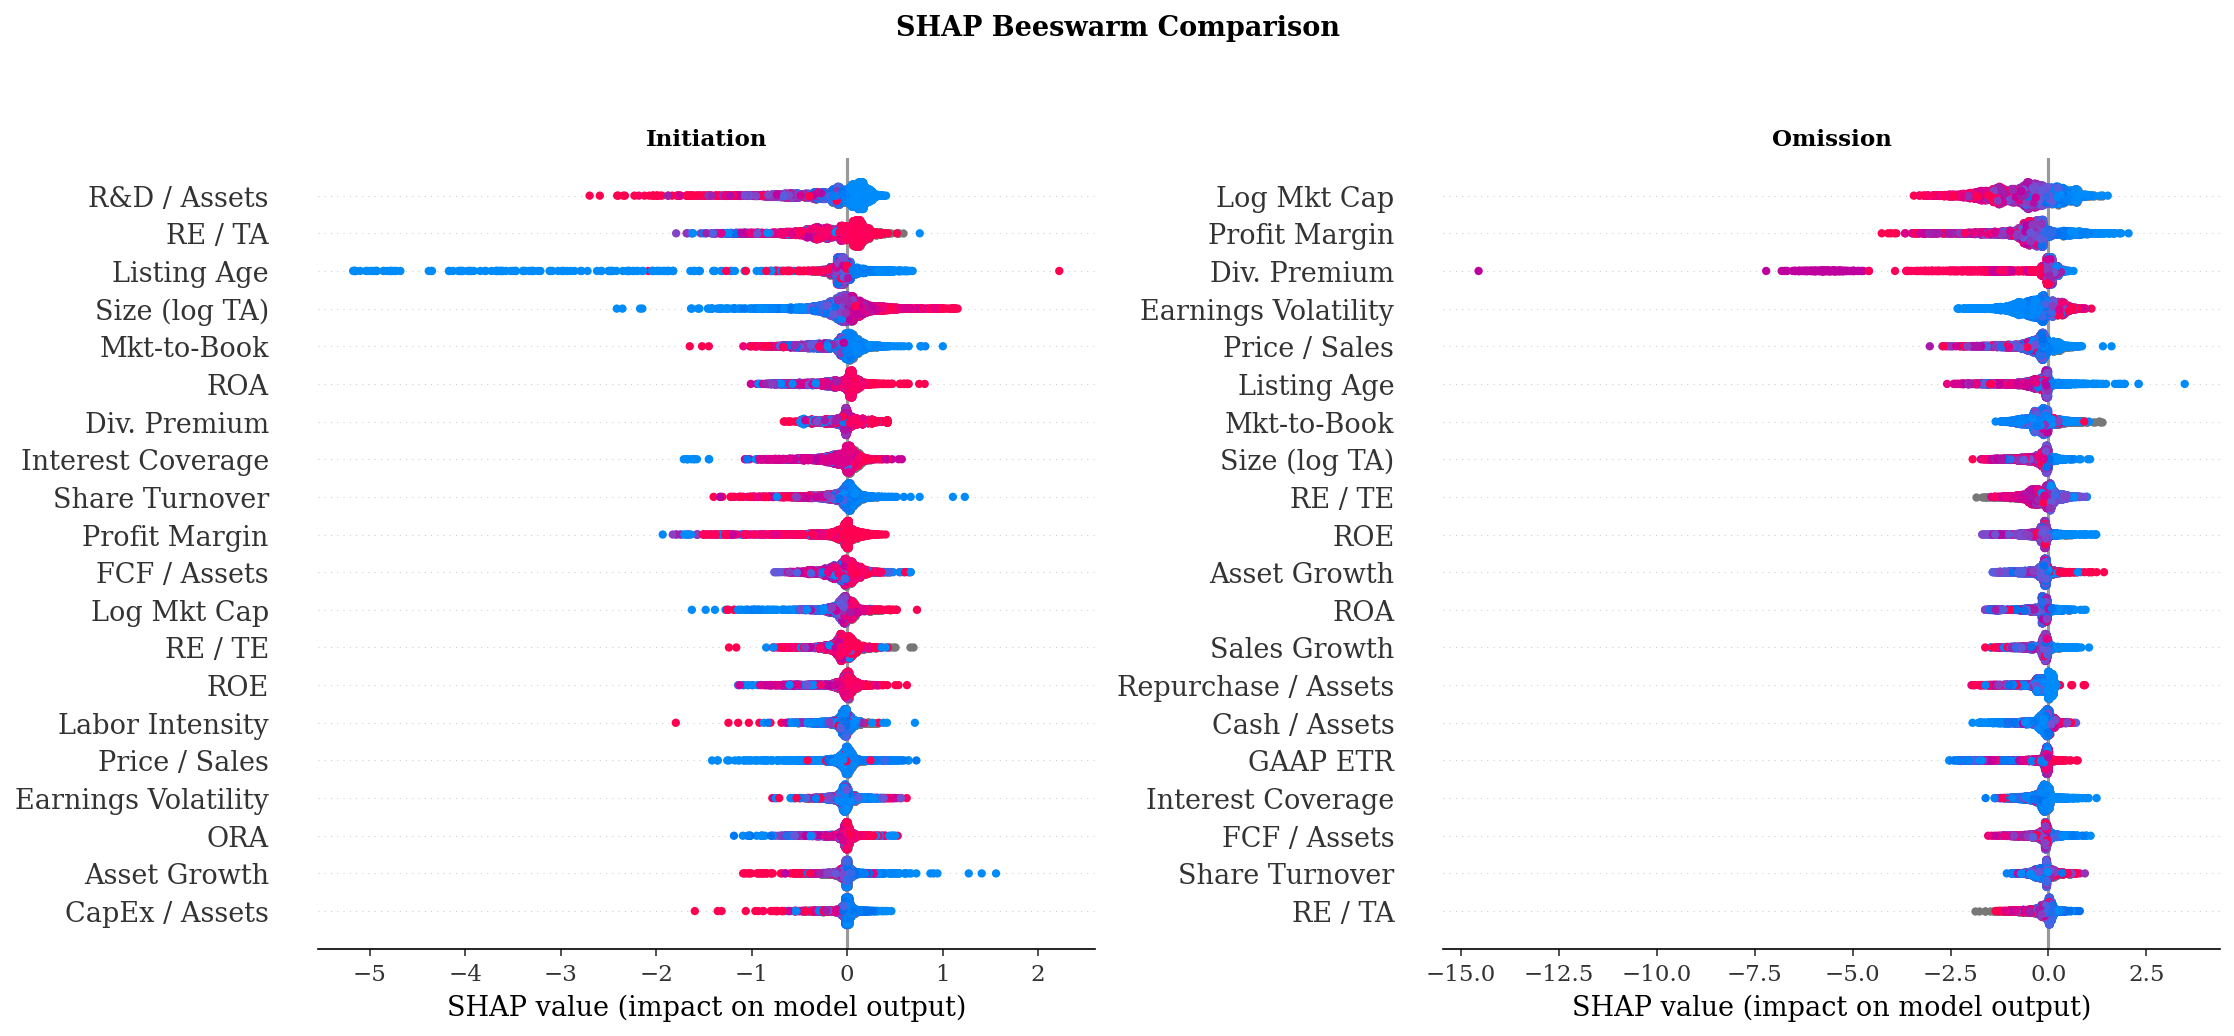

Saved → results/figures/shap_beeswarm_initiation_omission.png


In [21]:
def _sample_shap_for_task(task, max_n=5000):
    task_df = local_shap_df[local_shap_df['task'].eq(task)]
    if len(task_df) > max_n:
        task_df = task_df.sample(n=max_n, random_state=SEED)
    shap_vals = task_df[[f'shap_{feature}' for feature in FEATURES]].to_numpy()
    feature_vals = task_df[[f'value_{feature}' for feature in FEATURES]].copy()
    feature_vals.columns = [SHORT_LABELS.get(feature, feature) for feature in FEATURES]
    return shap_vals, feature_vals

fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=150)
for ax, task in zip(axes, ('initiation', 'omission')):
    shap_vals, feature_vals = _sample_shap_for_task(task)
    plt.sca(ax)
    shap.summary_plot(
        shap_vals,
        feature_vals,
        max_display=20,
        show=False,
        plot_size=None,
        color_bar=False,
    )
    ax.set_title(task.capitalize(), fontsize=11, fontweight='bold')

fig.suptitle('SHAP Beeswarm Comparison', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGS_DIR / 'shap_beeswarm_initiation_omission.png', bbox_inches='tight')
fig.savefig(FIGS_DIR / 'shap_beeswarm_initiation_omission.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figures/shap_beeswarm_initiation_omission.png")


## §9 — Size-adjusted theory-block dynamics

Figure 5.2 tracks which theoretical mechanism dominates XGBoost's predictions through time. For each block and fold year, the mean absolute SHAP contribution is summed across block members and divided by block size — preventing larger blocks from dominating mechanically (thesis Eq. 4.9–4.11). Values are then normalised to 100% within each year for relative comparison. Single-variable blocks are excluded because their size adjustment is trivially identical to their raw SHAP. Three market regimes are shaded: 2000–2009 (tax reform + GFC), 2010–2019 (reappearing dividends), 2020–2025 (COVID/post-COVID).

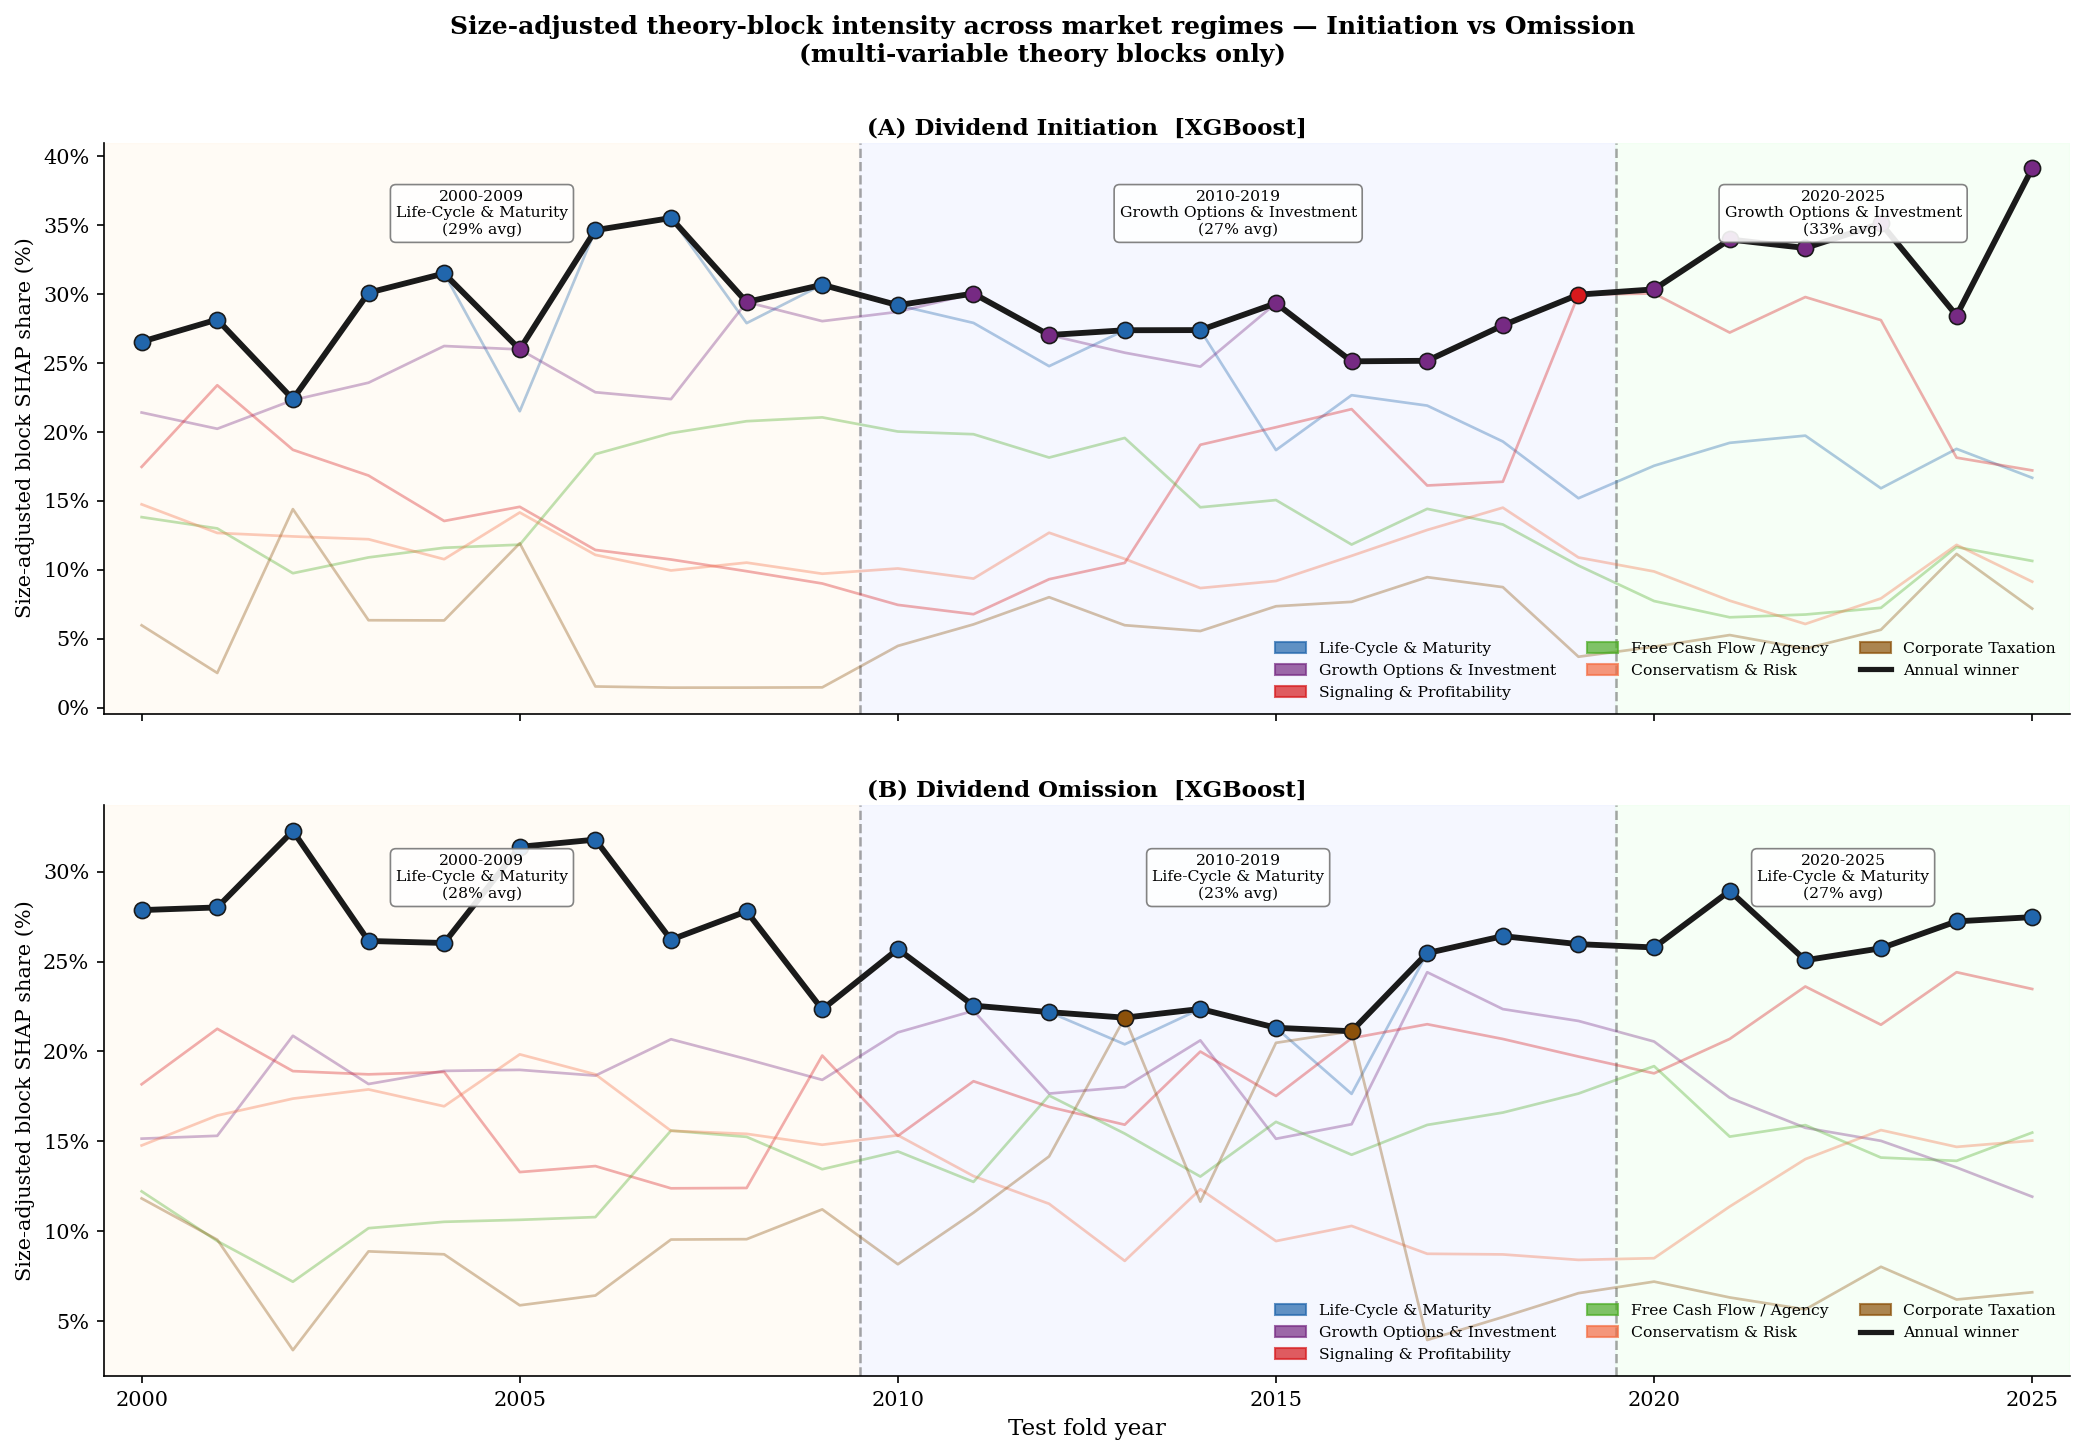

Saved → results/figures/shap_block_time_size_adjusted_multivar.png


In [ ]:
MULTI_VAR_BLOCKS = {
    block: feats
    for block, feats in THEORY_BLOCKS.items()
    if len(feats) > 1
}


def _block_fold_df_size_adjusted(task, as_pct=True):
    """Return fold-year size-adjusted block intensity for multi-variable blocks only.

    For each theory block and fold year:
        1. Sum mean absolute SHAP values within the block.
        2. Divide by the number of variables in the block.
        3. Optionally normalize within year so rows sum to 100%.
    """
    rows = {}

    for fold_year in sorted(shap_by_fold[task].keys()):
        mean_abs = shap_by_fold[task][fold_year]
        sv_ser = pd.Series(mean_abs, index=FEATURES)

        row = {}
        for block, feats in MULTI_VAR_BLOCKS.items():
            valid_feats = [feature for feature in feats if feature in sv_ser.index]

            if valid_feats:
                cumulative = sv_ser[valid_feats].sum()
                row[block] = cumulative / len(valid_feats)
            else:
                row[block] = np.nan

        rows[fold_year] = row

    df = pd.DataFrame(rows).T

    if as_pct:
        row_totals = df.sum(axis=1).replace(0, np.nan)
        df = df.div(row_totals, axis=0) * 100

    return df


TASK_LABELS = {'initiation': 'Dividend Initiation', 'omission': 'Dividend Omission'}
SHAP_LABEL = {'initiation': 'XGBoost', 'omission': 'XGBoost'}
REGIMES = [
    (2000, 2009, '2000-2009'),
    (2010, 2019, '2010-2019'),
    (2020, 2025, '2020-2025'),
]
REGIME_BREAKS = [2010, 2020]
REGIME_PALETTE = ['#FFF8EE', '#EEF2FF', '#EFFFEF']


fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=150, sharex=True)

for ax, task in zip(axes, ('initiation', 'omission')):
    fold_df = _block_fold_df_size_adjusted(task)
    panel = 'A' if task == 'initiation' else 'B'

    # Annual winning block
    winner_pct = fold_df.max(axis=1)
    winner_blk = fold_df.idxmax(axis=1)

    # Background regime shading
    for (r_start, r_end, _), r_col in zip(REGIMES, REGIME_PALETTE):
        ax.axvspan(
            r_start - 0.5,
            r_end + 0.5,
            color=r_col,
            alpha=0.55,
            zorder=0
        )

    # Vertical regime boundaries
    for brk in REGIME_BREAKS:
        ax.axvline(
            brk - 0.5,
            color=UU_GRAY,
            lw=1.2,
            ls='--',
            alpha=0.65,
            zorder=2
        )

    # Faded block trajectories
    for block in MULTI_VAR_BLOCKS:
        if block not in fold_df.columns:
            continue

        ax.plot(
            fold_df.index,
            fold_df[block],
            color=BLOCK_COLORS[block],
            lw=1.3,
            alpha=0.35,
            zorder=3,
            label=block.replace('\n', ' ')
        )

    # Annual winner envelope
    ax.plot(
        fold_df.index,
        winner_pct,
        color=UU_DARK,
        lw=2.8,
        zorder=5,
        label='Annual winner'
    )

    # Winner dots
    for yr in fold_df.index:
        blk = winner_blk.loc[yr]
        col = BLOCK_COLORS.get(blk, UU_GRAY)

        ax.scatter(
            yr,
            winner_pct.loc[yr],
            color=col,
            s=60,
            zorder=6,
            edgecolors=UU_DARK,
            linewidths=0.8
        )

    # Regime annotation boxes
    y_max = np.nanmax(fold_df.values)

    for r_start, r_end, r_label in REGIMES:
        regime_years = [
            yr for yr in fold_df.index
            if r_start <= yr <= r_end
        ]

        if not regime_years:
            continue

        regime_df = fold_df.loc[regime_years]
        dominant_blk = regime_df.mean().idxmax()
        dominant_avg = regime_df[dominant_blk].mean()
        mid_yr = (r_start + r_end) / 2

        ax.annotate(
            f'{r_label}\n'
            f'{dominant_blk.replace(chr(10), " ")}\n'
            f'({dominant_avg:.0f}% avg)',
            xy=(mid_yr, y_max * 0.96),
            ha='center',
            va='top',
            fontsize=7.5,
            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor='white',
                edgecolor=UU_GRAY,
                alpha=0.90,
                linewidth=0.8
            ),
            zorder=7
        )

    # Axes formatting
    ax.set_ylabel('Size-adjusted block SHAP share (%)', fontsize=10)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:.0f}%')
    )

    ax.set_title(
        f'({panel}) {TASK_LABELS[task]}  [{SHAP_LABEL[task]}]',
        fontsize=11,
        fontweight='bold',
        pad=4
    )

    # Legend
    block_patches = [
        mpatches.Patch(
            color=BLOCK_COLORS[b],
            alpha=0.7,
            label=b.replace('\n', ' ')
        )
        for b in MULTI_VAR_BLOCKS
        if b in fold_df.columns
    ]

    winner_line = plt.Line2D(
        [0],
        [0],
        color=UU_DARK,
        lw=2.5,
        label='Annual winner'
    )

    ax.legend(
        handles=block_patches + [winner_line],
        ncol=3,
        fontsize=7.5,
        frameon=False,
        loc='lower right'
    )


axes[-1].set_xlabel('Test fold year', fontsize=11)
axes[-1].set_xlim(
    fold_df.index.min() - 0.5,
    fold_df.index.max() + 0.5
)

fig.suptitle(
    'Size-adjusted theory-block intensity across market regimes — Initiation vs Omission\n'
    '(multi-variable theory blocks only)',
    fontsize=12,
    fontweight='bold',
    y=0.965
)

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.subplots_adjust(
    top=0.88,
    hspace=0.16
)

fig.savefig(
    FIGS_DIR / 'shap_block_time_size_adjusted_multivar.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved → results/figures/shap_block_time_size_adjusted_multivar.png")

## §10 — Time-varying SHAP table

Identifies the single most influential predictor in each test fold (Table 5.5). Provides a year-by-year narrative of which economic signal drives dividend prediction, complementing the block-level view in §9.

In [11]:
winning_variable_rows = []

for task in ('initiation', 'omission'):
    for fold_year in sorted(shap_by_fold[task].keys()):
        mean_abs = pd.Series(shap_by_fold[task][fold_year], index=FEATURES)

        winning_feature = mean_abs.idxmax()
        winning_value = mean_abs.loc[winning_feature]
        total_shap = mean_abs.sum()

        winning_variable_rows.append({
            'task': task,
            'year': fold_year,
            'winning_feature': winning_feature,
            'winning_variable': SHORT_LABELS.get(winning_feature, winning_feature),
            'theory_block': FEAT_TO_BLOCK.get(winning_feature, '').replace('\n', ' '),
            'mean_abs_shap': winning_value,
            'share_of_total_shap': winning_value / total_shap if total_shap > 0 else np.nan,
        })

winning_variable_by_year = pd.DataFrame(winning_variable_rows)

# Display clean table
display(
    winning_variable_by_year
    .assign(
        mean_abs_shap=lambda d: d['mean_abs_shap'].round(4),
        share_of_total_shap=lambda d: (d['share_of_total_shap'] * 100).round(2),
    )
)

# Save CSV
winning_variable_path = TABLES_DIR / 'winning_variable_by_year.csv'
winning_variable_by_year.to_csv(winning_variable_path, index=False)

# Save LaTeX table
latex_path = TABLES_DIR / 'winning_variable_by_year.tex'
latex_table = (
    winning_variable_by_year
    .assign(
        mean_abs_shap=lambda d: d['mean_abs_shap'].round(4),
        share_of_total_shap=lambda d: (d['share_of_total_shap'] * 100).round(2),
    )
    .rename(columns={
        'task': 'Task',
        'year': 'Year',
        'winning_variable': 'Winning variable',
        'theory_block': 'Theory block',
        'mean_abs_shap': 'Mean |SHAP|',
        'share_of_total_shap': 'Share of total SHAP (%)',
    })
    [['Task', 'Year', 'Winning variable', 'Theory block', 'Mean |SHAP|', 'Share of total SHAP (%)']]
    .to_latex(
        index=False,
        caption='Year-by-year winning variables based on fold-level mean absolute SHAP values.',
        label='tab:winning_variable_by_year',
        column_format='llp{3.2cm}p{4.2cm}rr',
        escape=True,
    )
)

with open(latex_path, 'w') as fh:
    fh.write(latex_table)

print(f"Saved → {winning_variable_path}")
print(f"Saved → {latex_path}")

,task,year,winning_feature,winning_variable,theory_block,mean_abs_shap,share_of_total_shap
0,initiation,2000,Listing_Age_lag1,Listing Age,Life-Cycle & Maturity,0.3532,8.350000
1,initiation,2001,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.2451,11.040000
2,initiation,2002,Profit_Margin_lag1,Profit Margin,Signaling & Profitability,0.4788,7.210000
3,initiation,2003,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.4756,18.150000
4,initiation,2004,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.4650,17.299999
5,initiation,2005,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.4411,7.270000
6,initiation,2006,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.2098,17.870001
7,initiation,2007,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.2203,19.430000
8,initiation,2008,Size_lag1,Size (log TA),Life-Cycle & Maturity,0.2583,10.350000
9,initiation,2009,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.2894,10.500000


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.csv
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.tex


## §11 — Investor screening

Table 5.6 and Figure 5.3. At the start of each fiscal year, all firms in the risk set are ranked by predicted event probability. Screening at top-5%, top-10%, and top-20% review budgets measures the practical value of the model: how many actual initiators or omitters would an investor catch by reviewing only the highest-scored firms?

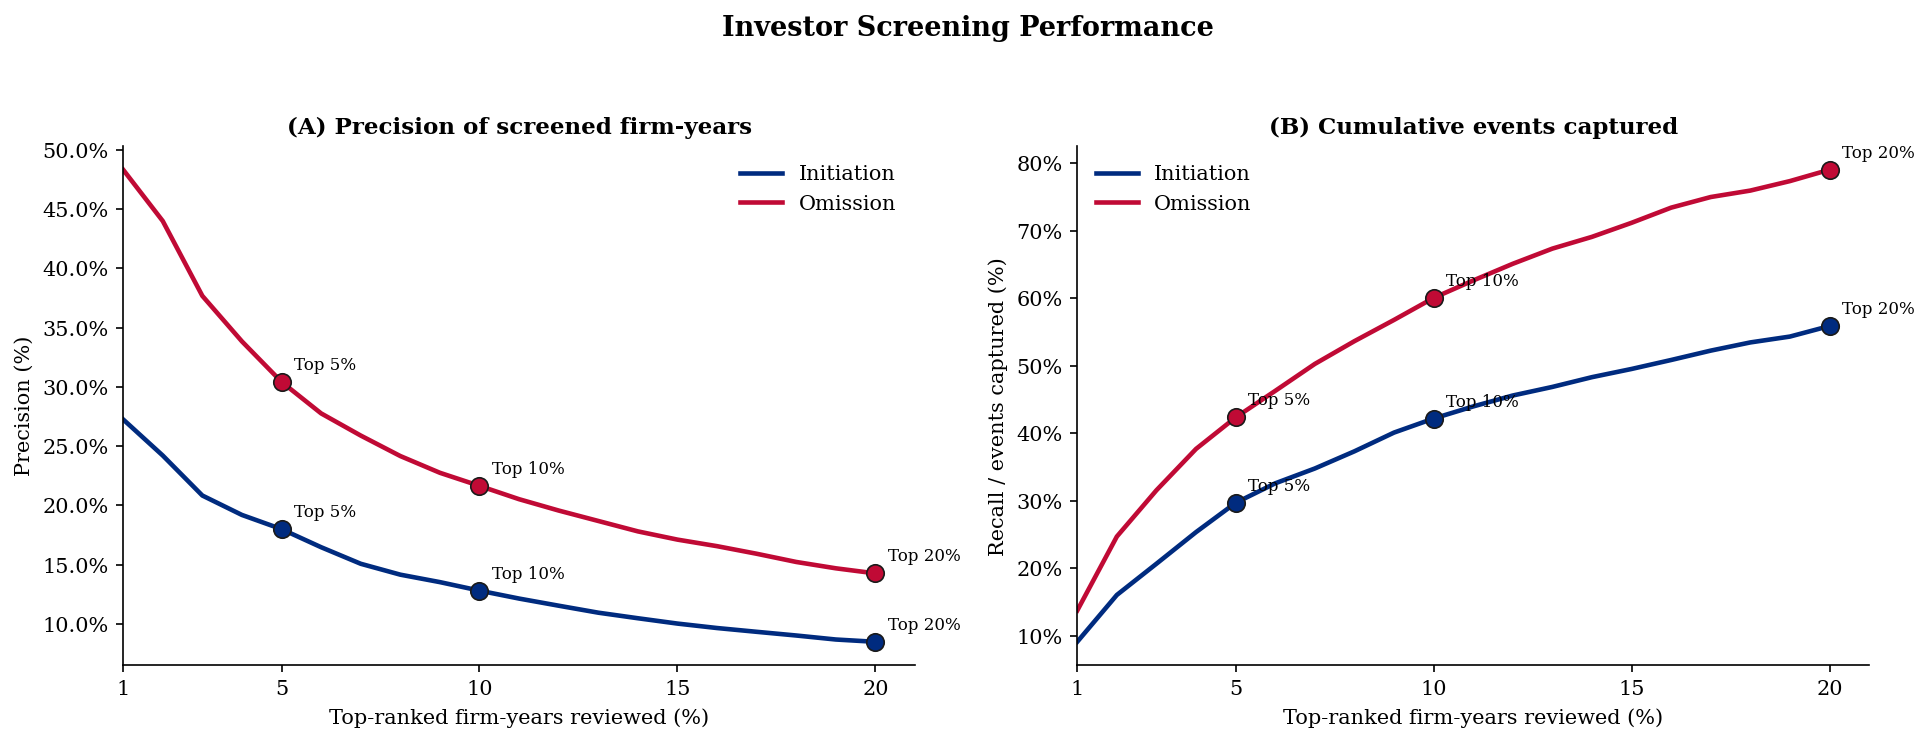

Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_top_percent.csv
Saved → results/figures/investor_screening_fold_level_curve.png


In [12]:
SCREEN_GRID = np.arange(0.01, 0.201, 0.01)
TABLE_PCTS = [0.05, 0.10, 0.20]

screen_rows = []
for task in ('initiation', 'omission'):
    task_df = local_shap_df[local_shap_df['task'].eq(task)]
    total_events = int(task_df['target_event'].sum())
    total_obs = len(task_df)
    base_rate = total_events / total_obs

    for pct in SCREEN_GRID:
        screened = 0
        captured = 0

        for _, fold_df in task_df.groupby('fold'):
            n_screen = max(1, int(np.ceil(len(fold_df) * pct)))
            chosen = fold_df.nlargest(n_screen, 'pred_prob')
            screened += len(chosen)
            captured += int(chosen['target_event'].sum())

        precision = captured / screened
        recall = captured / total_events

        screen_rows.append({
            'task': task,
            'top_percent': pct,
            'screened_firm_years': screened,
            'true_events_captured': captured,
            'total_events': total_events,
            'precision': precision,
            'recall': recall,
            'base_rate': base_rate,
            'lift_vs_base_rate': precision / base_rate,
        })

screen_curve = pd.DataFrame(screen_rows)
investor_screening = screen_curve[screen_curve['top_percent'].isin(TABLE_PCTS)].copy()
investor_screening_path = TABLES_DIR / 'investor_screening_top_percent.csv'
investor_screening.to_csv(investor_screening_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150, sharex=True)
for task, color in [('initiation', UU_BLUE), ('omission', UU_RED)]:
    d = screen_curve[screen_curve['task'].eq(task)]
    x = d['top_percent'] * 100

    axes[0].plot(x, d['precision'] * 100, color=color, lw=2.2, label=task.capitalize())
    axes[1].plot(x, d['recall'] * 100, color=color, lw=2.2, label=task.capitalize())

    for pct in TABLE_PCTS:
        point = d[np.isclose(d['top_percent'], pct)].iloc[0]
        for ax, y_col in [(axes[0], 'precision'), (axes[1], 'recall')]:
            ax.scatter(
                pct * 100,
                point[y_col] * 100,
                s=70,
                color=color,
                edgecolor=UU_DARK,
                linewidth=0.8,
                zorder=5,
            )
            ax.annotate(
                f'Top {int(pct * 100)}%',
                xy=(pct * 100, point[y_col] * 100),
                xytext=(6, 6),
                textcoords='offset points',
                fontsize=8,
            )

axes[0].set_title('(A) Precision of screened firm-years', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Cumulative events captured', fontsize=11, fontweight='bold')
for ax in axes:
    ax.set_xlabel('Top-ranked firm-years reviewed (%)')
    ax.set_xlim(1, 21)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(frameon=False)
axes[0].set_ylabel('Precision (%)')
axes[1].set_ylabel('Recall / events captured (%)')

fig.suptitle('Investor Screening Performance', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGS_DIR / 'investor_screening_fold_level_curve.png', bbox_inches='tight')
fig.savefig(FIGS_DIR / 'investor_screening_fold_level_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {investor_screening_path}')
print('Saved → results/figures/investor_screening_fold_level_curve.png')


## §12 — Single-year screening example

FY2024 watchlist illustration (Appendix A.2). Demonstrates the screening workflow for a single recent year, showing how many events fall inside each review budget.

In [13]:
EXAMPLE_YEAR = 2024
SCREEN_PCTS = [0.05, 0.10, 0.20]

rows = []
for task in ('initiation', 'omission'):
    year_df = (
        local_shap_df[
            local_shap_df['task'].eq(task)
            & local_shap_df['fold'].eq(EXAMPLE_YEAR)
        ]
        .copy()
        .sort_values('pred_prob', ascending=False)
    )

    if year_df.empty:
        raise ValueError(f'No rows found for task={task}, year={EXAMPLE_YEAR}.')

    total_firms = len(year_df)
    total_events = int(year_df['target_event'].sum())
    base_rate = total_events / total_firms

    for pct in SCREEN_PCTS:
        n_screen = max(1, int(np.ceil(total_firms * pct)))
        screened = year_df.head(n_screen)
        captured = int(screened['target_event'].sum())

        rows.append({
            'task': task,
            'year': EXAMPLE_YEAR,
            'screen': f'Top {int(pct * 100)}%',
            'universe_firms': total_firms,
            'screened_firms': n_screen,
            'actual_events_in_year': total_events,
            'events_captured': captured,
            'events_missed': total_events - captured,
            'precision': captured / n_screen,
            'recall': captured / total_events if total_events else np.nan,
            'base_rate': base_rate,
            'lift': (captured / n_screen) / base_rate,
        })

year_screening_summary = pd.DataFrame(rows)
display(
    year_screening_summary.assign(
        precision=lambda d: (d['precision'] * 100).round(2),
        recall=lambda d: (d['recall'] * 100).round(2),
        base_rate=lambda d: (d['base_rate'] * 100).round(2),
        lift=lambda d: d['lift'].round(2),
    )
)

year_screening_summary_path = TABLES_DIR / f'investor_screening_single_year_{EXAMPLE_YEAR}.csv'
year_screening_summary.to_csv(year_screening_summary_path, index=False)
print(f'Saved → {year_screening_summary_path}')


,task,year,screen,universe_firms,screened_firms,actual_events_in_year,events_captured,events_missed,precision,recall,base_rate,lift
0,initiation,2024,Top 5%,1495,75,29,6,23,8.00,20.69,1.94,4.12
1,initiation,2024,Top 10%,1495,150,29,13,16,8.67,44.83,1.94,4.47
2,initiation,2024,Top 20%,1495,299,29,16,13,5.35,55.17,1.94,2.76
3,omission,2024,Top 5%,1768,89,42,19,23,21.35,45.24,2.38,8.99
4,omission,2024,Top 10%,1768,177,42,24,18,13.56,57.14,2.38,5.71
5,omission,2024,Top 20%,1768,354,42,36,6,10.17,85.71,2.38,4.28


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_single_year_2024.csv


## §13 — Local SHAP plotting helpers

Reusable functions for case-study figures. All local explanations use saved out-of-sample XGBoost SHAP values from the walk-forward loop — no model is retrained for individual explanations.

In [14]:
def _local_case_title(row, task, status_label):
    firm = row.get('CompanyName', '')
    ticker = row.get('Ticker', '')
    firm_label = f"{firm} ({ticker})" if pd.notna(ticker) and str(ticker) else str(firm)
    return (
        f"{firm_label} — FY{int(row['FiscalYear'])}\n"
        f"{status_label} | target={int(row['target_event'])} | P({task})={row['pred_prob']:.3f}"
    )


def get_local_shap_case(task, firm_id=None, fiscal_year=None, ticker=None, company_contains=None, highest_prob=True):
    """Return one saved out-of-sample XGBoost SHAP case from local_shap_df."""
    case = local_shap_df[local_shap_df['task'].eq(task)].copy()
    if firm_id is not None:
        case = case[case['FirmID'].eq(firm_id)]
    if fiscal_year is not None:
        case = case[case['FiscalYear'].eq(fiscal_year)]
    if ticker is not None and 'Ticker' in case.columns:
        case = case[case['Ticker'].astype(str).str.upper().eq(str(ticker).upper())]
    if company_contains is not None and 'CompanyName' in case.columns:
        case = case[case['CompanyName'].astype(str).str.contains(company_contains, case=False, na=False)]
    if case.empty:
        raise ValueError('No saved local SHAP case matches the requested filters.')
    return case.sort_values('pred_prob', ascending=not highest_prob).iloc[0]


def plot_local_shap_row(ax, row, task, status_label, n_feats=15):
    """Stable horizontal signed-contribution plot for one saved local SHAP row."""
    shap_ser = pd.Series({feature: row[f'shap_{feature}'] for feature in FEATURES})
    sv_top = shap_ser[shap_ser.abs().nlargest(n_feats).index].sort_values()

    vals = sv_top.values
    labels = [SHORT_LABELS.get(feature, feature) for feature in sv_top.index]
    colors = [UU_GREEN if value >= 0 else UU_RED for value in vals]

    y_pos = np.arange(len(vals))
    ax.barh(y_pos, vals, color=colors, edgecolor='none', height=0.72)
    ax.axvline(0, color=UU_DARK, lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(f'SHAP value on model-score scale (→ increases {task} probability)', fontsize=10)
    ax.set_title(_local_case_title(row, task, status_label), fontsize=10.5, fontweight='bold', pad=6)

    for i, value in enumerate(vals):
        ha = 'left' if value >= 0 else 'right'
        offset = 0.001 if value >= 0 else -0.001
        ax.text(value + offset, i, f'{value:+.3f}', va='center', ha=ha, fontsize=7.5, color=UU_DARK)


def save_local_contribution_figure(row, task, status_label, filename_stem, n_feats=15):
    """Save one waterfall-style signed-contribution chart as PNG."""
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    plot_local_shap_row(ax, row, task, status_label, n_feats=n_feats)
    fig.suptitle('Local SHAP Contribution Chart\n(values are on the model-score scale)', fontsize=12, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    png_path = FIGS_DIR / f'{filename_stem}.png'
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return png_path


## §14 — Initiation case studies: Meta and Starbucks

Generates the named initiation cases used in the thesis discussion (§5.6). Meta FY2024 is a false negative where growth-option signals (R&D, Market-to-Book) suppress the initiation score despite life-cycle maturity. Starbucks FY2010 is a true positive where size and free cash flow dominate.

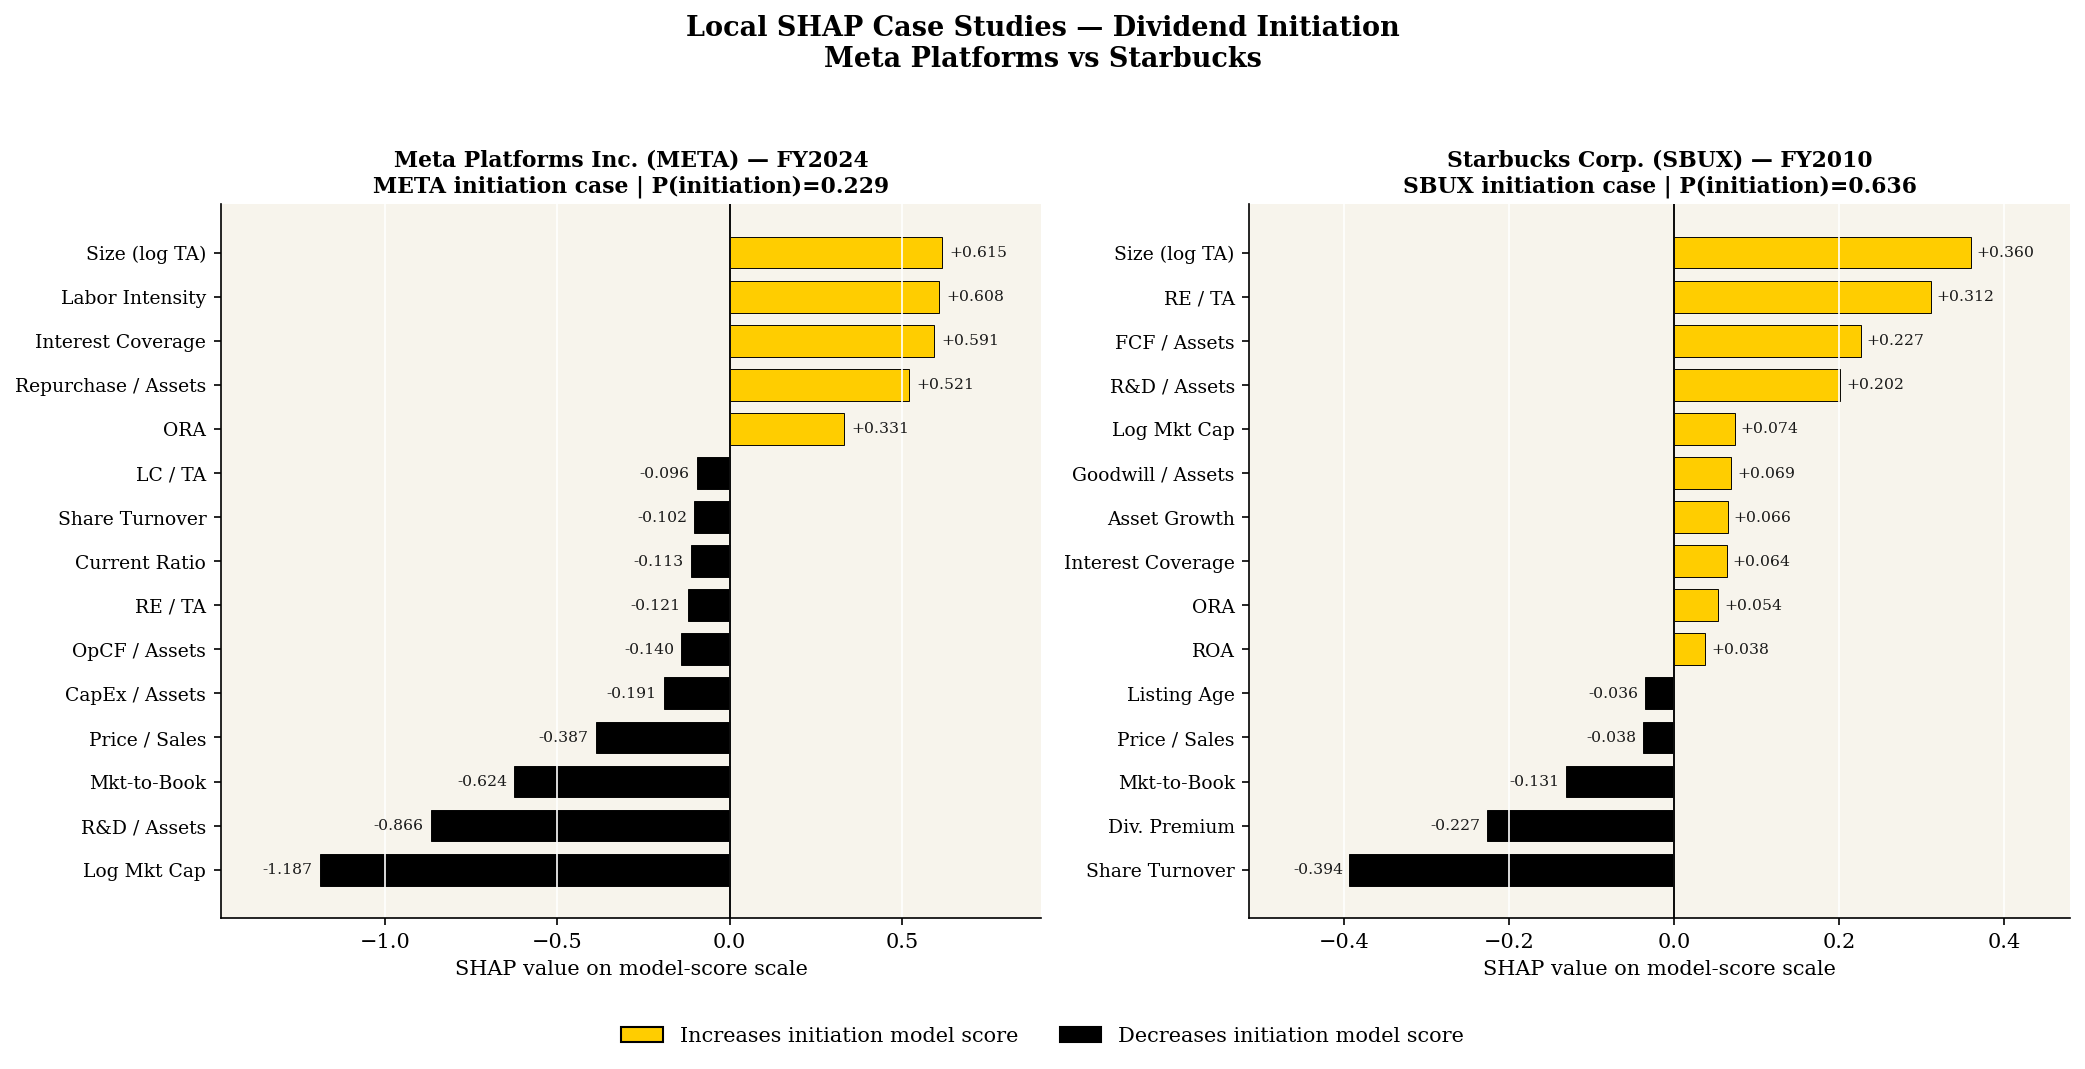

Saved → results/figures/shap_case_studies_initiation.png
Saved → results/figures/shap_waterfall_initiation_{case_left,case_right}.png


In [26]:
# ── Utrecht colours ────────────────────────────────────────────────────────
UU_YELLOW = '#FFCD00'
UU_BLACK  = '#000000'
UU_DARK   = '#1A1A1A'
UU_LIGHT  = '#F7F4EC'

POS_COLOR = UU_YELLOW   # positive SHAP: increases score
NEG_COLOR = UU_BLACK    # negative SHAP: decreases score


def plot_local_shap_row(ax, row, task, status_label, n_feats=15):
    """Local SHAP contribution plot — Utrecht yellow/black style."""
    shap_ser = pd.Series({
        feature: row[f'shap_{feature}']
        for feature in FEATURES
        if f'shap_{feature}' in row.index
    })
    top_idx = shap_ser.abs().nlargest(n_feats).index
    sv_top  = shap_ser[top_idx].sort_values()

    vals   = sv_top.values
    labels = [SHORT_LABELS.get(f, f) for f in sv_top.index]
    colors = [POS_COLOR if v >= 0 else NEG_COLOR for v in vals]
    y_pos  = np.arange(len(vals))

    ax.set_facecolor(UU_LIGHT)
    ax.barh(y_pos, vals, color=colors, edgecolor=UU_BLACK,
            linewidth=0.45, height=0.72)
    ax.axvline(0, color=UU_BLACK, lw=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('SHAP value on model-score scale', fontsize=10)

    firm   = row.get('display_name', row.get('CompanyName', ''))
    ticker = row.get('Ticker', '')
    firm_label = f"{firm} ({ticker})" if pd.notna(ticker) and str(ticker) else str(firm)
    ax.set_title(
        f"{firm_label} — FY{int(row['FiscalYear'])}\n"
        f"{status_label} | P({task})={row['pred_prob']:.3f}",
        fontsize=10.5, fontweight='bold', pad=6,
    )

    max_abs = max(abs(vals).max(), 0.01)
    for i, value in enumerate(vals):
        ha, offset = ('left', 0.018 * max_abs) if value >= 0 else ('right', -0.018 * max_abs)
        ax.text(value + offset, i, f'{value:+.3f}',
                va='center', ha=ha, fontsize=7.5, color=UU_DARK)

    ax.grid(axis='x', color='white', linewidth=0.8)
    ax.grid(axis='y', visible=False)

    # Expand x-axis to prevent annotation clipping on extreme bars
    xl = ax.get_xlim()
    pad = 0.10 * (xl[1] - xl[0])
    ax.set_xlim(xl[0] - pad, xl[1] + pad)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(UU_BLACK)
    ax.spines['bottom'].set_color(UU_BLACK)


def save_local_contribution_figure(row, task, status_label, filename_stem, n_feats=15):
    """Save one Utrecht-style local SHAP chart as PNG."""
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    fig.patch.set_facecolor('white')
    plot_local_shap_row(ax, row, task, status_label, n_feats=n_feats)

    pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                               label=f'Increases {task} model score')
    neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                               label=f'Decreases {task} model score')
    fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
               ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('Local SHAP Contribution Chart', fontsize=12, fontweight='bold')
    fig.tight_layout(rect=[0, 0.04, 1, 0.93])

    png_path = FIGS_DIR / f'{filename_stem}.png'
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return png_path


# ── Select Meta and Starbucks cases ────────────────────────────────────────
INIT_CASES = [
    {
        'key': 'case_left',
        'label': 'META',
        'firm_id': 170617,
        'fiscal_year': 2024,
        'display_name': 'Meta Platforms Inc.',
    },
    {
        'key': 'case_right',
        'label': 'SBUX',
        'firm_id': 25434,
        'fiscal_year': 2010,
        'display_name': 'Starbucks Corp.',
    },
]

selected_init_cases = []
for spec in INIT_CASES:
    row = get_local_shap_case(
        'initiation',
        firm_id=spec['firm_id'],
        fiscal_year=spec['fiscal_year'],
        highest_prob=True,
    ).copy()
    row['case_label'] = spec['label']
    row['display_name'] = spec['display_name']
    selected_init_cases.append(row)

# ── Combined figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(selected_init_cases),
                         figsize=(7 * len(selected_init_cases), 7), dpi=150)
fig.patch.set_facecolor('white')
if len(selected_init_cases) == 1:
    axes = [axes]

for ax, row, spec in zip(axes, selected_init_cases, INIT_CASES):
    status = f"{spec['label']} initiation case"
    plot_local_shap_row(ax, row, 'initiation', status)

pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                           label='Increases initiation model score')
neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                           label='Decreases initiation model score')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Local SHAP Case Studies — Dividend Initiation\n'
             'Meta Platforms vs Starbucks',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(FIGS_DIR / 'shap_case_studies_initiation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Separate waterfall figures ─────────────────────────────────────────────
for row, spec in zip(selected_init_cases, INIT_CASES):
    save_local_contribution_figure(
        row, 'initiation',
        f"{spec['label']} initiation case",
        f"shap_waterfall_initiation_{spec['key']}",
    )

print("Saved → results/figures/shap_case_studies_initiation.png")
print("Saved → results/figures/shap_waterfall_initiation_{case_left,case_right}.png")

## §15 — Appendix B: Alphabet case

Alphabet FY2024 (Appendix B.1). Same false-negative mechanism as Meta —
high R\&D intensity and Market-to-Book override life-cycle maturity signals.
Shown alongside Meta for direct comparison.

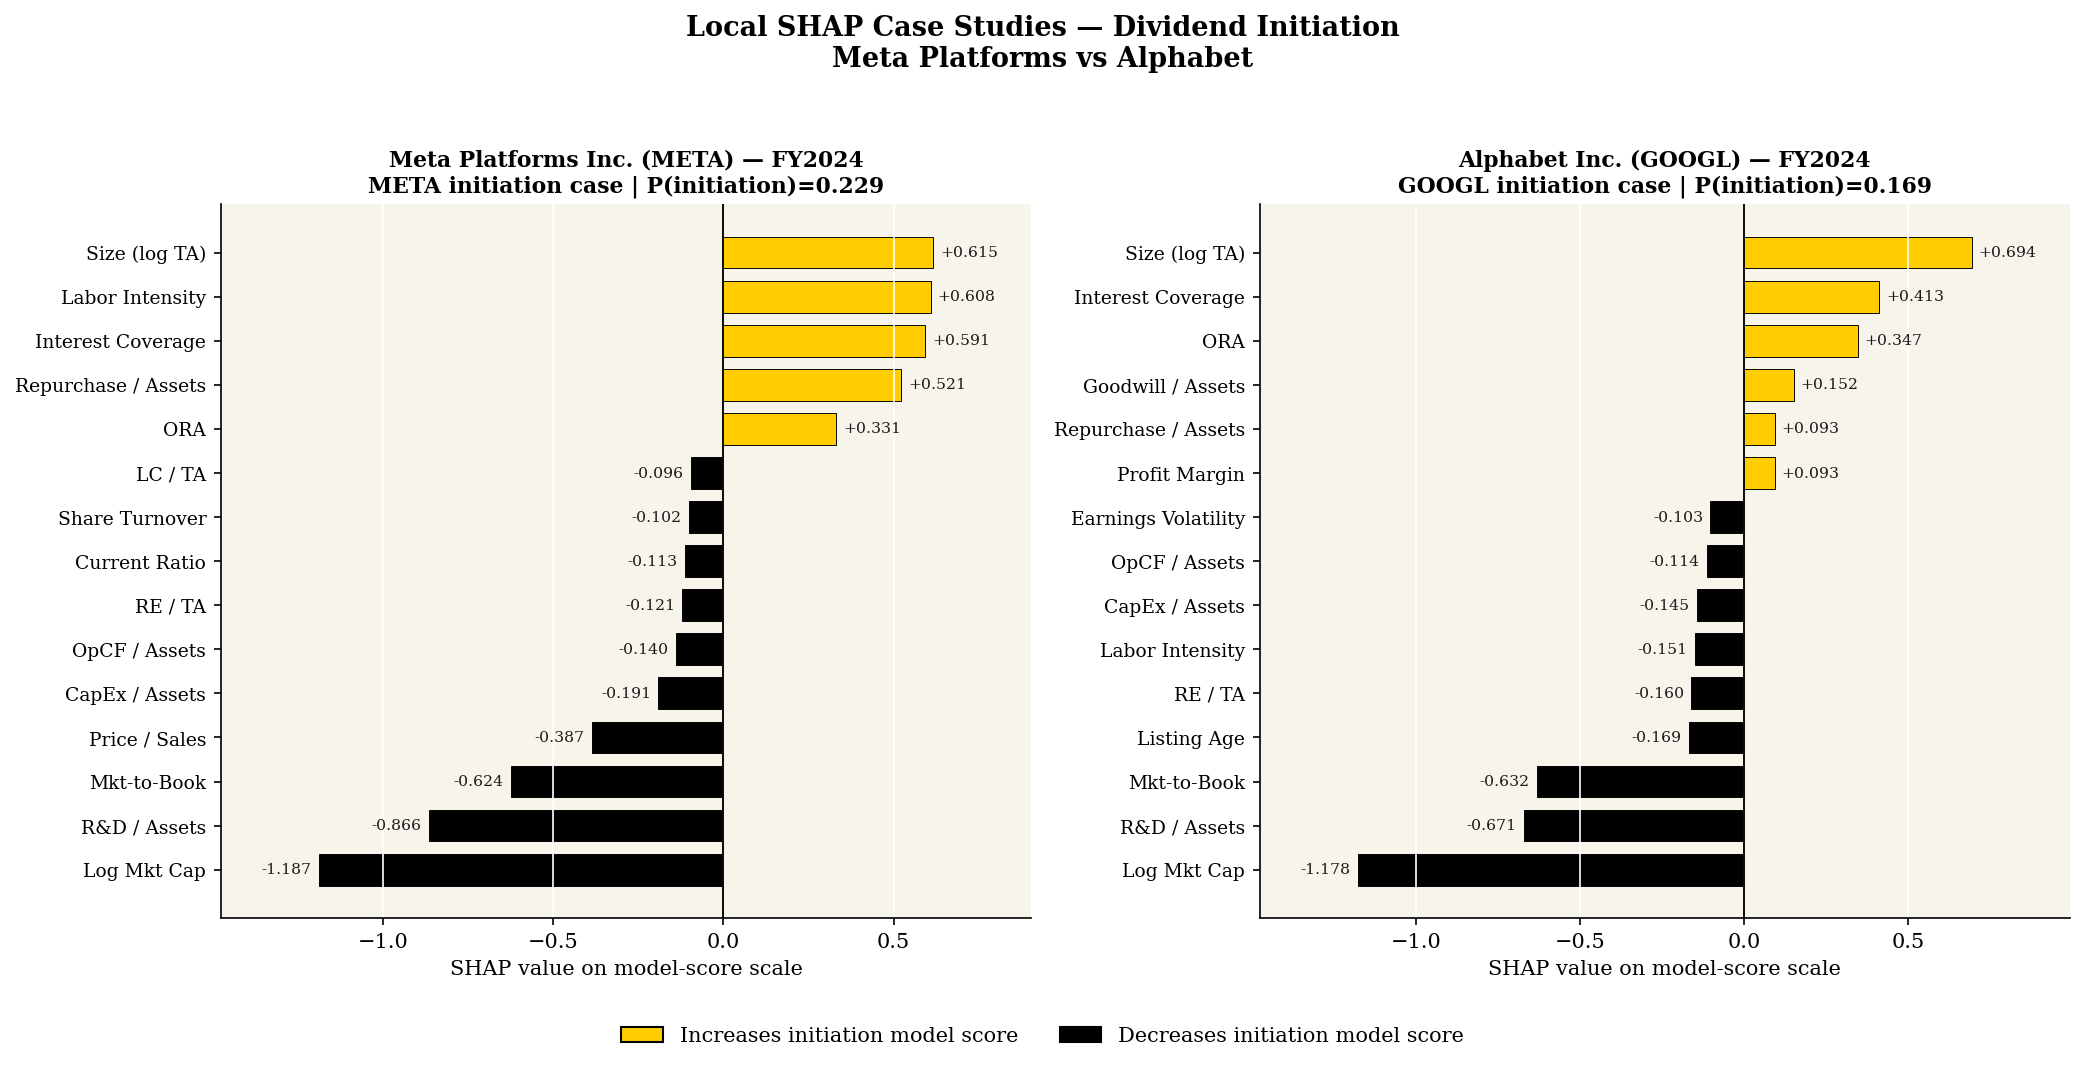

Alphabet case: {'FirmID': np.int64(160329), 'FiscalYear': np.int64(2024), 'Ticker': 'GOOGL', 'CompanyName': 'ALPHABET INC', 'pred_prob': np.float32(0.1688284), 'target_event': np.int64(1)}
Saved → results/figures/shap_case_studies_initiation_meta_alphabet.png
Saved → results/figures/shap_waterfall_initiation_alphabet.png


In [27]:
def get_alphabet_case():
    """Return Alphabet's FY2024 initiation row from saved local SHAP results."""
    for ticker in ['GOOGL', 'GOOG']:
        try:
            return get_local_shap_case(
                'initiation',
                ticker=ticker,
                fiscal_year=2024,
                highest_prob=True,
            ).copy()
        except ValueError:
            pass

    return get_local_shap_case(
        'initiation',
        company_contains='Alphabet',
        fiscal_year=2024,
        highest_prob=True,
    ).copy()


ALPHABET_CASE = get_alphabet_case()

# ── Side-by-side: Meta vs Alphabet (Appendix B.1) ─────────────────────────
meta_row = selected_init_cases[0]  # META from §14 above

APPENDIX_CASES = [
    {'row': meta_row,       'label': 'META',  'display_name': 'Meta Platforms Inc.'},
    {'row': ALPHABET_CASE,  'label': 'GOOGL', 'display_name': 'Alphabet Inc.'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=150)
fig.patch.set_facecolor('white')

for ax, spec in zip(axes, APPENDIX_CASES):
    spec['row']['display_name'] = spec['display_name']
    plot_local_shap_row(ax, spec['row'], 'initiation',
                        f"{spec['label']} initiation case")

pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                           label='Increases initiation model score')
neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                           label='Decreases initiation model score')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Local SHAP Case Studies — Dividend Initiation\n'
             'Meta Platforms vs Alphabet',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(FIGS_DIR / 'shap_case_studies_initiation_meta_alphabet.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Standalone Alphabet waterfall ──────────────────────────────────────────
save_local_contribution_figure(
    ALPHABET_CASE, 'initiation',
    'Alphabet initiation case',
    'shap_waterfall_initiation_alphabet',
)

cols = ['FirmID', 'FiscalYear', 'Ticker', 'CompanyName', 'pred_prob', 'target_event']
available_cols = [c for c in cols if c in ALPHABET_CASE.index]
print('Alphabet case:', dict(ALPHABET_CASE[available_cols]))
print("Saved → results/figures/shap_case_studies_initiation_meta_alphabet.png")
print("Saved → results/figures/shap_waterfall_initiation_alphabet.png")

## §16 — Intel omission case

Intel FY2025 omission case study (§5.6). A true positive where operational distress signals (collapsing margins, earnings volatility) overcome the negative contribution from Intel's historically large market capitalisation.

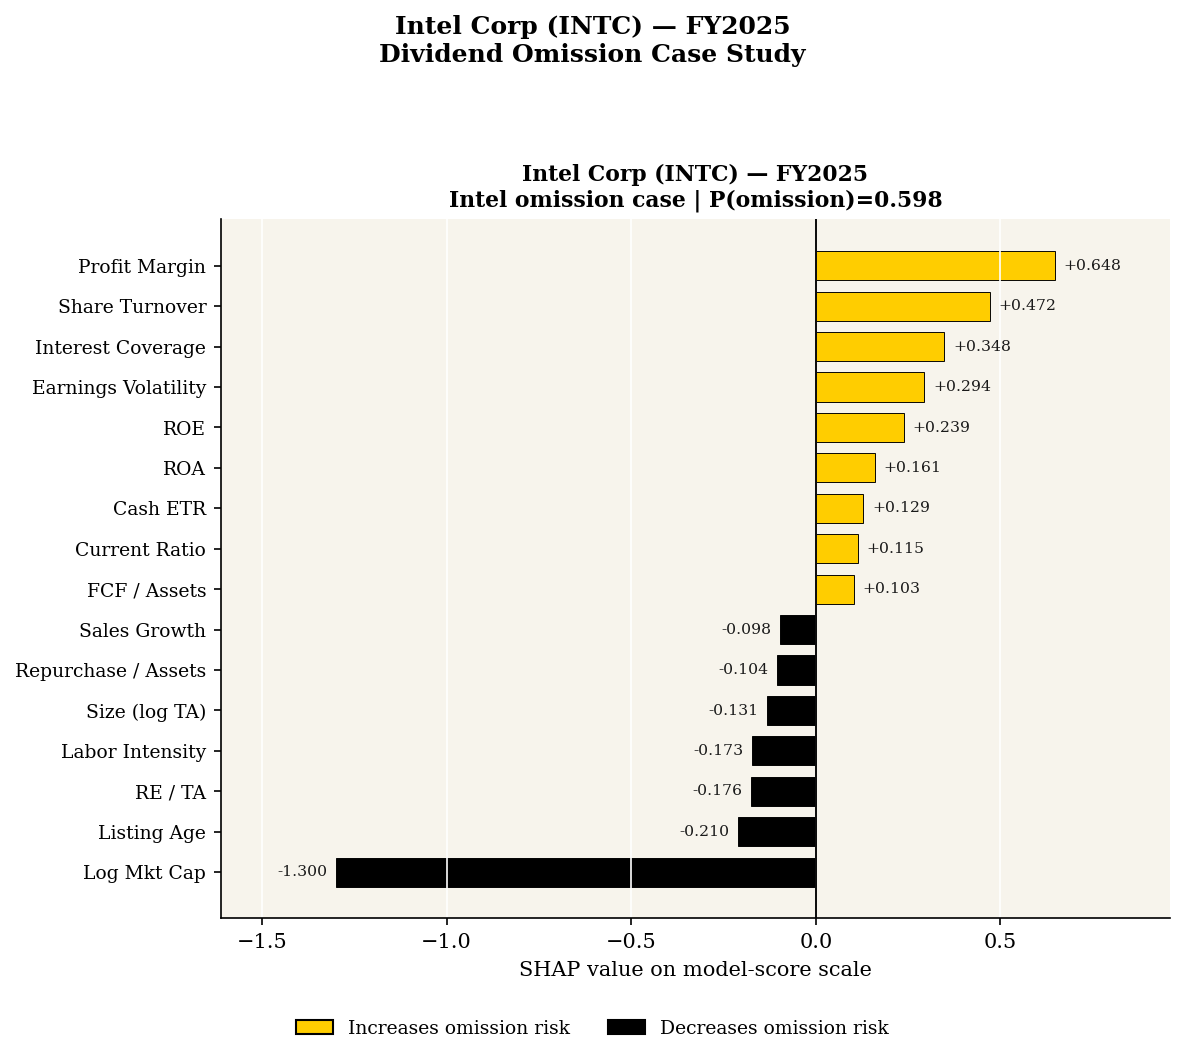

,CompanyName,Ticker,FiscalYear,pred_prob,target_event,rank_in_year,universe_firms,rank_percentile,actual_events_in_year
0,INTEL CORP,INTC,2025,0.5979,1,197,1582,12.45,41


Saved → results/figures/shap_case_study_omission_intel.png
Saved → results/figures/shap_waterfall_omission_intel.png
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/intel_omission_case_overview.csv


In [28]:
def get_intel_case():
    """Return Intel's FY2025 omission row from saved local SHAP results."""
    try:
        return get_local_shap_case(
            'omission',
            ticker='INTC',
            fiscal_year=2025,
            highest_prob=True,
        ).copy()
    except ValueError:
        return get_local_shap_case(
            'omission',
            company_contains='Intel',
            fiscal_year=2025,
            highest_prob=True,
        ).copy()


INTEL_CASE = get_intel_case()

intel_fold = local_shap_df[
    local_shap_df['task'].eq('omission')
    & local_shap_df['fold'].eq(int(INTEL_CASE['fold']))
].copy()
intel_rank = int(intel_fold['pred_prob'].rank(method='first', ascending=False).loc[INTEL_CASE.name])
intel_universe = len(intel_fold)
intel_events = int(intel_fold['target_event'].sum())

intel_overview = pd.DataFrame([{
    'CompanyName': INTEL_CASE.get('CompanyName', ''),
    'Ticker': INTEL_CASE.get('Ticker', ''),
    'FiscalYear': int(INTEL_CASE['FiscalYear']),
    'pred_prob': float(INTEL_CASE['pred_prob']),
    'target_event': int(INTEL_CASE['target_event']),
    'rank_in_year': intel_rank,
    'universe_firms': intel_universe,
    'rank_percentile': intel_rank / intel_universe,
    'actual_events_in_year': intel_events,
}])

# ── Inline display ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
fig.patch.set_facecolor('white')
INTEL_CASE['display_name'] = 'Intel Corp'
plot_local_shap_row(ax, INTEL_CASE, 'omission', 'Intel omission case', n_feats=16)

pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                           label='Increases omission risk')
neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                           label='Decreases omission risk')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Intel Corp (INTC) — FY2025\nDividend Omission Case Study',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 0.93])
fig.savefig(FIGS_DIR / 'shap_case_study_omission_intel.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Standalone waterfall (same style, saved separately) ────────────────────
save_local_contribution_figure(
    INTEL_CASE, 'omission',
    'Intel omission case',
    'shap_waterfall_omission_intel',
    n_feats=16,
)

intel_overview_path = TABLES_DIR / 'intel_omission_case_overview.csv'
intel_overview.to_csv(intel_overview_path, index=False)

display(
    intel_overview.assign(
        pred_prob=lambda d: d['pred_prob'].round(4),
        rank_percentile=lambda d: (100 * d['rank_percentile']).round(2),
    )
)
print('Saved → results/figures/shap_case_study_omission_intel.png')
print('Saved → results/figures/shap_waterfall_omission_intel.png')
print(f'Saved → {intel_overview_path}')

## §17 — Run-complete summary

Final checklist of all thesis-facing output files produced by this notebook.

In [18]:
NEW_TABLE_PATHS = [
    TABLES_DIR / 'performance.tex',
    TABLES_DIR / 'performance.csv',
    TABLES_DIR / 'local_shap_values_all_firm_years.csv.gz',
    TABLES_DIR / 'winning_variable_by_year.csv',
    TABLES_DIR / 'winning_variable_by_year.tex',
    TABLES_DIR / 'investor_screening_top_percent.csv',
    TABLES_DIR / 'investor_screening_single_year_2024.csv',
    TABLES_DIR / 'xgb_pr_auc_wilcoxon_tests.csv',
    TABLES_DIR / 'xgb_pr_auc_wilcoxon_tests.tex',
    TABLES_DIR / 'intel_omission_case_overview.csv',
]
NEW_FIGURE_PATHS = [
    FIGS_DIR / 'shap_beeswarm_initiation_omission.png',
    FIGS_DIR / 'shap_block_time_size_adjusted_multivar.png',
    FIGS_DIR / 'investor_screening_fold_level_curve.png',
    FIGS_DIR / 'shap_case_studies_initiation.png',
    FIGS_DIR / 'shap_waterfall_initiation_case_left.png',
    FIGS_DIR / 'shap_waterfall_initiation_case_right.png',
    FIGS_DIR / 'shap_waterfall_initiation_alphabet.png',
    FIGS_DIR / 'shap_waterfall_omission_intel.png',
]

print('RUN COMPLETE')
print('-' * 72)
print(f'Model-fold records       : {len(df_rec):,}')
print(f'local_shap_df rows       : {len(local_shap_df):,}')
print(f'Performance table shape  : {perf_mean.shape}')
print()
print('Saved table paths:')
for path in NEW_TABLE_PATHS:
    print(f'  - {path}')
print()
print('Saved figure paths:')
for path in NEW_FIGURE_PATHS:
    print(f'  - {path}')


RUN COMPLETE
------------------------------------------------------------------------
Model-fold records       : 312
local_shap_df rows       : 105,942
Performance table shape  : (12, 4)

Saved table paths:
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/performance.tex
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/performance.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/local_shap_values_all_firm_years.csv.gz
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.tex
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_top_percent.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_single_year_2024.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/xgb_pr_auc_wilcoxon_tests.csv
  - /Users/mat

Exception ignored in: <function ResourceTracker.__del__ at 0x104e79bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104ee9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10606dbc0>
Traceback (most recent call last